In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [2]:
data = {
    "HH_ZZ_ZH_QCD": {
        "TRUTH_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification/SM_ggF_VBF_ZZ_ZH_2023_PostBPix_filter_abs_neg_weights_norm_by_sample_JetGoodFromHiggsOrdered_test.h5",
        "PRED_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification/SM_ggF_VBF_ZZ_ZH_2023_PostBPix_filter_abs_neg_weights_norm_by_sample_JetGoodFromHiggsOrdered_test_output.h5",
        "CLASS_NAMES"        : ["ggF", "VBF", "ZH", "ZZ", "QCD"],
        "CLASS_NAMES_MERGED" : ["HH",        "ZH", "ZZ", "QCD"],   # ggF (0) + VBF (1) → HH (0)
        "MERGE_MAP": {0: 0, 1: 0, 2: 1, 3: 2, 4: 3}
    },
    "HH_QCD": {
        "TRUTH_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers/out_HH_DATA_classification_only/SM_HH_DATA_JetGoodFromHiggsOrdered_filter_abs_neg_weights_norm_by_sample_JetGoodFromHiggsOrdered_test.h5",
        "PRED_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers/out_HH_DATA_classification_only/SM_HH_DATA_JetGoodFromHiggsOrdered_filter_abs_neg_weights_norm_by_sample_JetGoodFromHiggsOrdered_test_output.h5",
        "CLASS_NAMES"        : ["HH", "QCD"],
    },
    # "HH_ZZ_ZH_QCD_ste2_PhaseA": {
    #     "TRUTH_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers/out_HH_ZH_ZZ_DATA_classification_step_2_phaseA_frozen/SM_HH_DATA_JetGoodFromHiggsOrdered_filter_abs_neg_weights_norm_by_sample_JetGoodFromHiggsOrdered_test.h5",
    #     "PRED_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers/out_HH_ZH_ZZ_DATA_classification_step_2_phaseA_frozen/SM_HH_ZH_ZZ_DATA_JetGoodFromHiggsOrdered_filter_abs_neg_weights_norm_by_sample_JetGoodFromHiggsOrdered_test_output.h5",
    #     "CLASS_NAMES"        : ["HH", "QCD", "ZH", "ZZ"],
    #     "HHvsQCD" : True,
    #     "CLASS_NAMES_HHvsQCD"        : ["HH", "QCD"],
    # },
    # "HH_ZZ_ZH_QCD_ste2_PhaseB": {
    #     "TRUTH_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_unfrozen/SM_HH_DATA_JetGoodFromHiggsOrdered_filter_abs_neg_weights_norm_by_sample_JetGoodFromHiggsOrdered_test.h5",
    #     "PRED_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_unfrozen/SM_HH_ZH_ZZ_DATA_JetGoodFromHiggsOrdered_filter_abs_neg_weights_norm_by_sample_JetGoodFromHiggsOrdered_test_output.h5",
    #     "CLASS_NAMES"        : ["HH", "QCD", "ZH", "ZZ"],
    #     "HHvsQCD" : True,
    #     "CLASS_NAMES_HHvsQCD"        : ["HH", "QCD"],
    # },
    # "HH_QCD_v2": {
    #     "TRUTH_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_DATA_classification_only/SM_HH_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test.h5",
    #     "PRED_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_DATA_classification_only/SM_HH_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test_output.h5",
    #     "CLASS_NAMES"        : ["HH", "QCD"],
    # },
    # "HH_ZZ_ZH_QCD_ste2_PhaseA_v2": {
    #     "TRUTH_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseA_frozen/SM_HH_HZ_ZZ_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test.h5",
    #     "PRED_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseA_frozen/SM_HH_HZ_ZZ_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test_output.h5",
    #     "CLASS_NAMES"        : ["HH", "QCD", "ZH", "ZZ"],
    #     "HHvsQCD" : True,
    #     "CLASS_NAMES_HHvsQCD"        : ["HH", "QCD"],
    # },
    # "HH_ZZ_ZH_QCD_ste2_PhaseB_v2": {
    #     "TRUTH_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_unfrozen/SM_HH_HZ_ZZ_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test.h5",
    #     "PRED_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_unfrozen/SM_HH_HZ_ZZ_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test_output.h5",
    #     "CLASS_NAMES"        : ["HH", "QCD", "ZH", "ZZ"],
    #     "HHvsQCD" : True,
    #     "CLASS_NAMES_HHvsQCD"        : ["HH", "QCD"],
    # },
    # "HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued": {
    #     "TRUTH_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_unfrozen/SM_HH_HZ_ZZ_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test.h5",
    #     "PRED_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_continued/out_seed_trainings_100/version_0/SM_HH_HZ_ZZ_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test_output.h5",
    #     "CLASS_NAMES"        : ["HH", "QCD", "ZH", "ZZ"],
    #     "HHvsQCD" : True,
    #     "CLASS_NAMES_HHvsQCD"        : ["HH", "QCD"],
    # },
    "HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continued": {
        "TRUTH_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_continued/out_seed_trainings_100/version_0/SM_HH_HZ_ZZ_4bDATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test.h5",
        "PRED_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_continued/out_seed_trainings_100/version_0/SM_HH_HZ_ZZ_4bDATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test_output.h5",
        "CLASS_NAMES"        : ["HH", "QCD", "ZH", "ZZ"],
        "HHvsQCD" : True,
        "CLASS_NAMES_HHvsQCD"        : ["HH", "QCD"],
    },
    "HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued_2": {
        "TRUTH_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_unfrozen/SM_HH_HZ_ZZ_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test.h5",
        "PRED_FILE": "/work/bevila_t/PostDoc/HH4b/Output/ML_trainings/SPANet_classification/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_continued_v2/version_0/SM_HH_HZ_ZZ_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test_output.h5",
        "CLASS_NAMES"        : ["HH", "QCD", "ZH", "ZZ"],
        "HHvsQCD" : True,
        "CLASS_NAMES_HHvsQCD"        : ["HH", "QCD"],
    },
    "ggF_VBF_ZZ_ZH_QCD_step3": {
        "TRUTH_FILE": "/pnfs/psi.ch/cms/trivcat/store/user/bevila_t/PostDoc/HH4b/ml_trainings/spanet/out_ggF_VBF_DATA_classification_only_v2_step_3/SM_ggF_VBF_HZ_ZZ_2bDATA_filter_abs_neg_weights_norm_by_sample_downsc_fact_0p05_JetTotalSPANetPadded_test.h5",
        "PRED_FILE": "/pnfs/psi.ch/cms/trivcat/store/user/bevila_t/PostDoc/HH4b/ml_trainings/spanet/out_ggF_VBF_DATA_classification_only_v2_step_3/out_seed_trainings_100/version_0/SM_ggF_VBF_HZ_ZZ_2bDATA_filter_abs_neg_weights_norm_by_sample_downsc_fact_0p05_JetTotalSPANetPadded_test_output.h5",
        "CLASS_NAMES"        : ["ggFHH", "VBFHH", "QCD", "ZH", "ZZ"],
        "HHvsQCD" : True,
        "CLASS_NAMES_HHvsQCD"        : ["HH", "QCD"],
        "VBFvsggF" : True,
        "CLASS_NAMES_VBFvsggF"        : ["ggFHH", "VBFHH"],
        # "CLASS_NAMES_MERGED" : ["HH",        "ZH", "ZZ", "QCD"],   # ggF (0) + VBF (1) → HH (0)
        # "MERGE_MAP": {0: 0, 1: 0, 2: 1, 3: 2, 4: 3}
    },
    "ggF_VBF_ZZ_ZH_QCD_step3_continued_600ep": {
        "TRUTH_FILE": "/pnfs/psi.ch/cms/trivcat/store/user/bevila_t/PostDoc/HH4b/ml_trainings/spanet/out_ggF_VBF_DATA_classification_only_v2_step_3/SM_ggF_VBF_HZ_ZZ_2bDATA_filter_abs_neg_weights_norm_by_sample_downsc_fact_0p05_JetTotalSPANetPadded_test.h5",
        "PRED_FILE": "/pnfs/psi.ch/cms/trivcat/store/user/bevila_t/PostDoc/HH4b/ml_trainings/spanet/out_ggF_VBF_DATA_classification_only_v2_step_3_continued_600ep/out_seed_trainings_100/version_0/SM_ggF_VBF_HZ_ZZ_2bDATA_filter_abs_neg_weights_norm_by_sample_downsc_fact_0p05_JetTotalSPANetPadded_test_output.h5",
        "CLASS_NAMES"        : ["ggFHH", "VBFHH", "QCD", "ZH", "ZZ"],
        "HHvsQCD" : True,
        "CLASS_NAMES_HHvsQCD"        : ["HH", "QCD"],
        "VBFvsggF" : True,
        "CLASS_NAMES_VBFvsggF"        : ["ggFHH", "VBFHH"],
        # "CLASS_NAMES_MERGED" : ["HH",        "ZH", "ZZ", "QCD"],   # ggF (0) + VBF (1) → HH (0)
        # "MERGE_MAP": {0: 0, 1: 0, 2: 1, 3: 2, 4: 3}
    },
}

In [3]:
N_PREVIEW = 3  # number of sample events to print per training

for training in data:
    with h5py.File(data[training]["TRUTH_FILE"], "r") as f:
        data[training]["y_true"] = f["CLASSIFICATIONS/EVENT/class"][:]
        data[training]["weight"] = f["WEIGHTS/weight"][:]

    with h5py.File(data[training]["PRED_FILE"], "r") as f:
        data[training]["y_pred_probs"] = f["CLASSIFICATIONS/EVENT/class"][:]

        data[training]["y_pred"] = np.argmax(data[training]["y_pred_probs"], axis=1)
        data[training]["labels"] = np.arange(len(data[training]["CLASS_NAMES"]))

        if data[training].get("HHvsQCD", False):
            if not ("ggFHH" in data[training]["CLASS_NAMES"] and "VBFHH" in data[training]["CLASS_NAMES"]):
                # Layout: [HH=0, QCD=1, ZH=2, ZZ=3]
                mask_HHvsQCD = data[training]["y_true"] < 2
                denom = (data[training]["y_pred_probs"][:, 0] + data[training]["y_pred_probs"][:, 1])[:, np.newaxis]
                data[training]["y_pred_probs_HHvsQCD"] = data[training]["y_pred_probs"][:, :2] / denom
                data[training]["y_pred_HHvsQCD"] = np.argmax(data[training]["y_pred_probs_HHvsQCD"], axis=1)

                data[training]["y_true_HHvsQCD"] = data[training]["y_true"][mask_HHvsQCD]
                data[training]["y_pred_HHvsQCD"] = data[training]["y_pred_HHvsQCD"][mask_HHvsQCD]
                data[training]["weight_HHvsQCD"] = data[training]["weight"][mask_HHvsQCD]
                data[training]["score_HHvsQCD"] = data[training]["y_pred_probs_HHvsQCD"][mask_HHvsQCD, 0]
                data[training]["labels_HHvsQCD"] = np.arange(2)
            else:
                # Layout: [ggFHH=0, VBFHH=1, QCD=2, ZH=3, ZZ=4]
                mask_HHvsQCD = data[training]["y_true"] < 3  # ggFHH + VBFHH + QCD
                denom = (data[training]["y_pred_probs"][:, 0] + data[training]["y_pred_probs"][:, 1] + data[training]["y_pred_probs"][:, 2])[:, np.newaxis]
                num   = (data[training]["y_pred_probs"][:, 0] + data[training]["y_pred_probs"][:, 1])[:, np.newaxis]
                data[training]["y_pred_probs_HHvsQCD"] = np.hstack([num / denom, data[training]["y_pred_probs"][:, 2:3] / denom])
                data[training]["y_pred_HHvsQCD"] = np.argmax(data[training]["y_pred_probs_HHvsQCD"], axis=1)

                # remap true labels: ggFHH(0) + VBFHH(1) -> HH(0), QCD(2) -> QCD(1)
                y_true_masked = data[training]["y_true"][mask_HHvsQCD]
                data[training]["y_true_HHvsQCD"] = np.where(y_true_masked < 2, 0, 1)
                data[training]["y_pred_HHvsQCD"] = data[training]["y_pred_HHvsQCD"][mask_HHvsQCD]
                data[training]["weight_HHvsQCD"] = data[training]["weight"][mask_HHvsQCD]
                data[training]["score_HHvsQCD"] = data[training]["y_pred_probs_HHvsQCD"][mask_HHvsQCD, 0]
                data[training]["labels_HHvsQCD"] = np.arange(2)

        if data[training].get("VBFvsggF", False):
            mask_VBFvsggF = data[training]["y_true"] < 2
            denom = (data[training]["y_pred_probs"][:, 0] + data[training]["y_pred_probs"][:, 1])[:, np.newaxis]
            data[training]["y_pred_probs_VBFvsggF"] = data[training]["y_pred_probs"][:, :2] / denom
            data[training]["y_pred_VBFvsggF"] = np.argmax(data[training]["y_pred_probs_VBFvsggF"], axis=1)

            data[training]["y_true_VBFvsggF"] = data[training]["y_true"][mask_VBFvsggF]
            data[training]["y_pred_VBFvsggF"] = data[training]["y_pred_VBFvsggF"][mask_VBFvsggF]
            data[training]["weight_VBFvsggF"] = data[training]["weight"][mask_VBFvsggF]
            data[training]["score_VBFvsggF"] = data[training]["y_pred_probs_VBFvsggF"][mask_VBFvsggF, 0]
            data[training]["labels_VBFvsggF"] = np.arange(2)

    if data[training].get("MERGE_MAP", False):
        data[training]["y_true_merged"] = np.vectorize(data[training]["MERGE_MAP"].__getitem__)(data[training]["y_true"])
        data[training]["y_pred_merged"] = np.vectorize(data[training]["MERGE_MAP"].__getitem__)(data[training]["y_pred"])
        data[training]["labels_merged"] = np.arange(len(data[training]["CLASS_NAMES_MERGED"]))

    # ── per-event sanity check ─────────────────────────────────────────────────
    cnames = data[training]["CLASS_NAMES"]
    n_tot  = len(data[training]["y_true"])
    print(f"\n{'='*72}")
    print(f"  Training : {training}")
    print(f"  Classes  : {cnames}")
    print(f"  Total events : {n_tot}  |  showing first {N_PREVIEW}")
    print(f"{'='*72}")
    for i in range(N_PREVIEW):
        raw      = data[training]["y_pred_probs"][i]
        true_idx = int(data[training]["y_true"][i])
        pred_idx = int(data[training]["y_pred"][i])
        match    = "✓" if true_idx == pred_idx else "✗"
        print(f"\n  Event {i}  true={cnames[true_idx]:<8}  pred={cnames[pred_idx]:<8} {match}  weight={data[training]['weight'][i]:.4f}")
        # raw probs with class labels
        raw_str = "  ".join(f"{n}={v:.4f}" for n, v in zip(cnames, raw))
        print(f"    Raw probs  :  {raw_str}  [sum={raw.sum():.6f}]")
        # HHvsQCD renormalised row (y_pred_probs_HHvsQCD is the full unmasked array)
        if "y_pred_probs_HHvsQCD" in data[training]:
            p   = data[training]["y_pred_probs_HHvsQCD"][i]
            nms = data[training].get("CLASS_NAMES_HHvsQCD", ["HH", "QCD"])
            p_str = "  ".join(f"{n}={v:.4f}" for n, v in zip(nms, p))
            print(f"    HHvsQCD    :  {p_str}  [sum={p.sum():.6f}]  → argmax={nms[int(np.argmax(p))]}")
        # VBFvsggF renormalised row (y_pred_probs_VBFvsggF is the full unmasked array)
        if "y_pred_probs_VBFvsggF" in data[training]:
            p   = data[training]["y_pred_probs_VBFvsggF"][i]
            nms = data[training].get("CLASS_NAMES_VBFvsggF", ["ggFHH", "VBFHH"])
            p_str = "  ".join(f"{n}={v:.4f}" for n, v in zip(nms, p))
            print(f"    VBFvsggF   :  {p_str}  [sum={p.sum():.6f}]  → argmax={nms[int(np.argmax(p))]}")
    print()


  Training : HH_ZZ_ZH_QCD
  Classes  : ['ggF', 'VBF', 'ZH', 'ZZ', 'QCD']
  Total events : 245132  |  showing first 3

  Event 0  true=VBF       pred=QCD      ✗  weight=0.0000
    Raw probs  :  ggF=0.0427  VBF=0.2668  ZH=0.2124  ZZ=0.0064  QCD=0.4717  [sum=1.000000]

  Event 1  true=QCD       pred=QCD      ✓  weight=0.0000
    Raw probs  :  ggF=0.2907  VBF=0.1635  ZH=0.1062  ZZ=0.0023  QCD=0.4373  [sum=1.000000]

  Event 2  true=QCD       pred=QCD      ✓  weight=0.0000
    Raw probs  :  ggF=0.0267  VBF=0.1360  ZH=0.0623  ZZ=0.0023  QCD=0.7728  [sum=1.000000]


  Training : HH_QCD
  Classes  : ['HH', 'QCD']
  Total events : 108135  |  showing first 3

  Event 0  true=HH        pred=HH       ✓  weight=0.0000
    Raw probs  :  HH=0.9967  QCD=0.0033  [sum=1.000000]

  Event 1  true=HH        pred=HH       ✓  weight=0.0000
    Raw probs  :  HH=0.5080  QCD=0.4920  [sum=1.000000]

  Event 2  true=QCD       pred=QCD      ✓  weight=0.0000
    Raw probs  :  HH=0.0581  QCD=0.9419  [sum=1.000000]


In [4]:
def plot_confusion(cm, class_names, title, fname, fmt=".2f"):
    lbs = np.arange(len(class_names))
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues", vmin=0)
    ax.set_xticks(lbs)
    ax.set_yticks(lbs)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(j, i, format(val, fmt), ha="center", va="center",
                    color="white" if val > cm.max() / 2 else "black")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(fname, dpi=150)
    print(f"saved {fname}")

In [5]:
def plot_roc(roc_data, title, fname, training):
    """
    roc_data: list of (fpr, tpr, roc_auc, label) tuples
    """
    fig, ax = plt.subplots(figsize=(6, 5))
    for fpr, tpr, roc_auc, label in roc_data:
        ax.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(title=training, fontsize=8)
    fig.tight_layout()
    fig.savefig(fname, dpi=150)
    print(f"saved {fname}")

saved HH_ZZ_ZH_QCD_roc_HH_merged.png
saved HH_ZZ_ZH_QCD_roc.png
saved HH_QCD_roc.png
saved HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continued_roc_HH_vs_QCD.png
saved HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continued_roc.png


/tmp/ipykernel_1387606/2553980637.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_1387606/2553980637.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(fname, dpi=150)


saved HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued_2_roc_HH_vs_QCD.png


/tmp/ipykernel_1387606/2553980637.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_1387606/2553980637.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(fname, dpi=150)


saved HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued_2_roc.png


...

/tmp/ipykernel_1387606/2553980637.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_1387606/2553980637.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(fname, dpi=150)


saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600ep_roc_HH_vs_QCD.png
saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600ep_roc_VBF_vs_ggF.png


/tmp/ipykernel_1387606/2553980637.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_1387606/2553980637.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(fname, dpi=150)


saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600ep_roc.png


/work/bevila_t/PostDoc/micromamba/envs/my-pocket-coffea/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


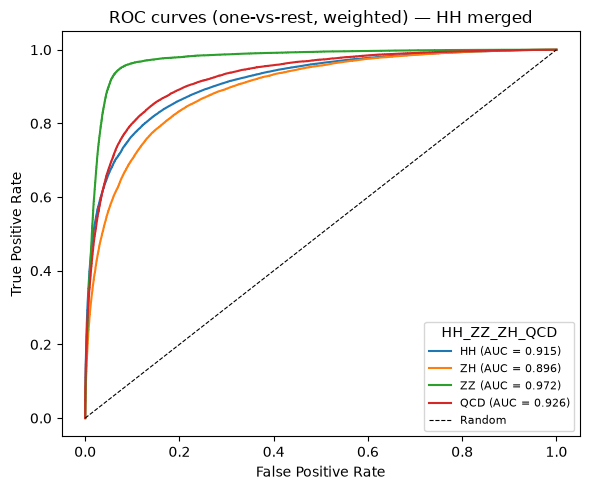

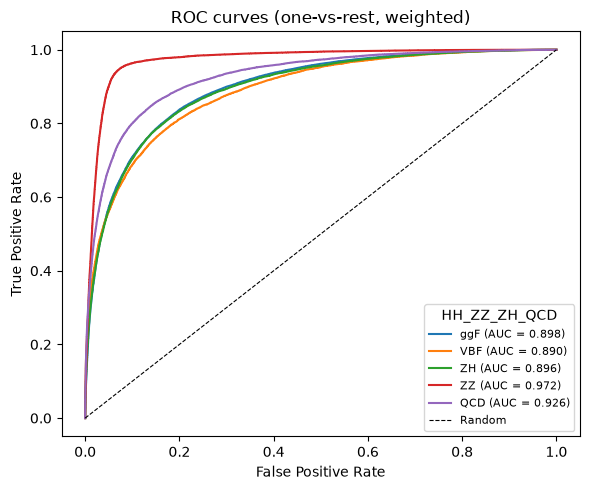

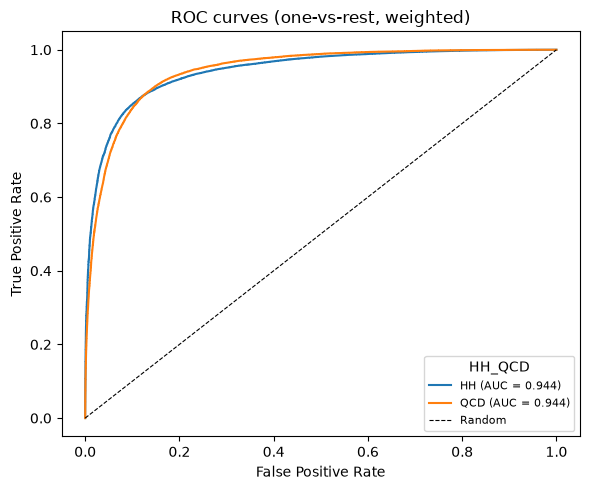

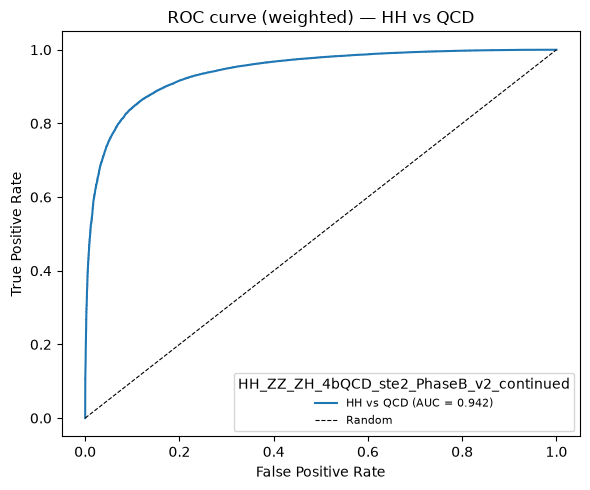

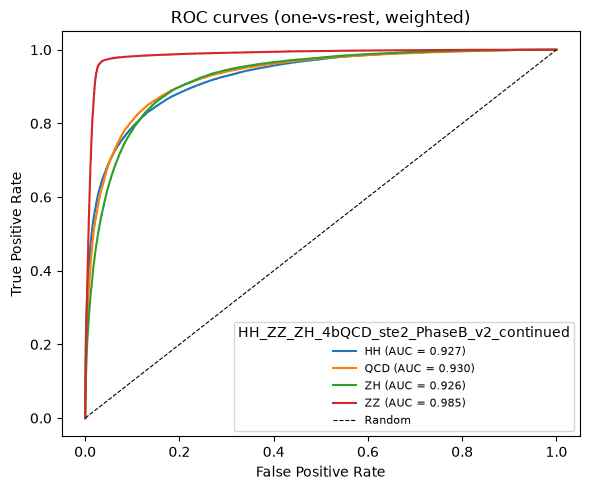

/work/bevila_t/PostDoc/micromamba/envs/my-pocket-coffea/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


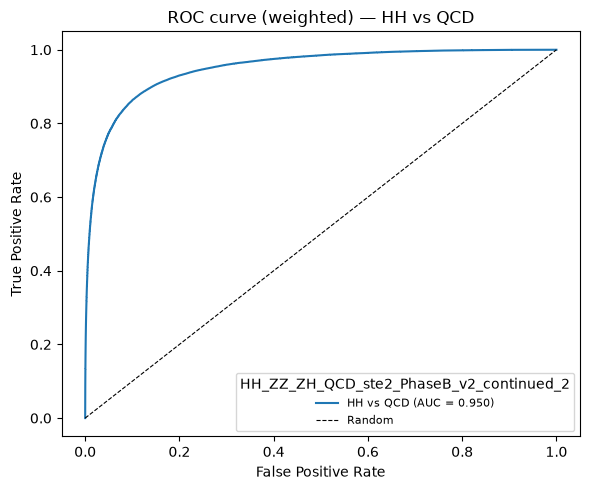

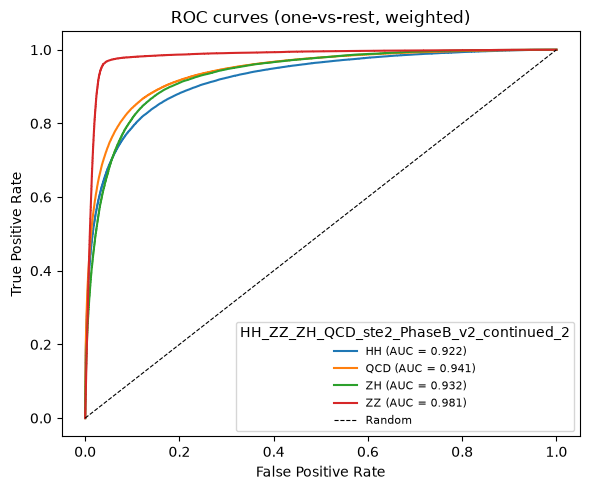

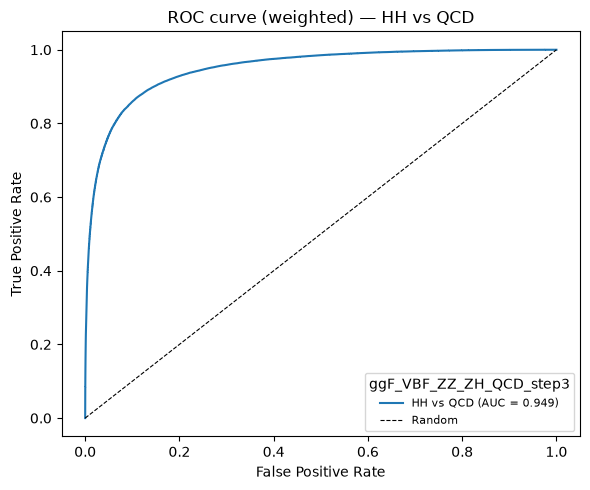

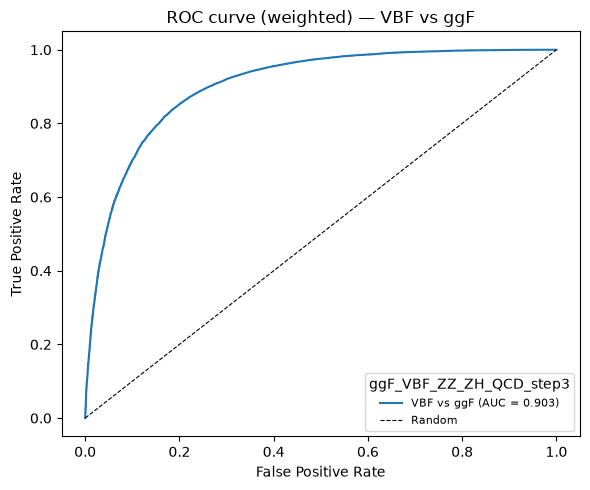

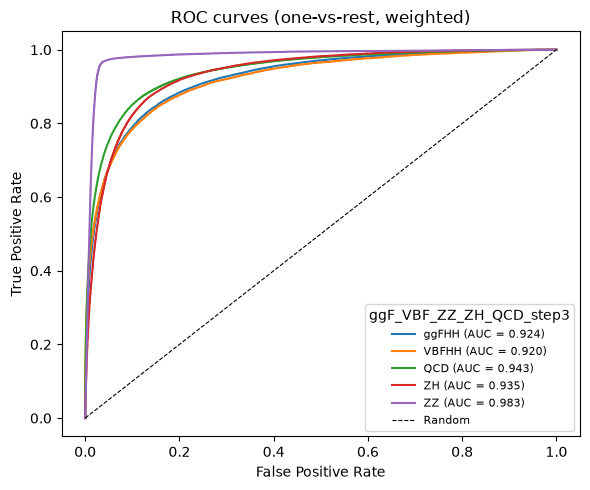

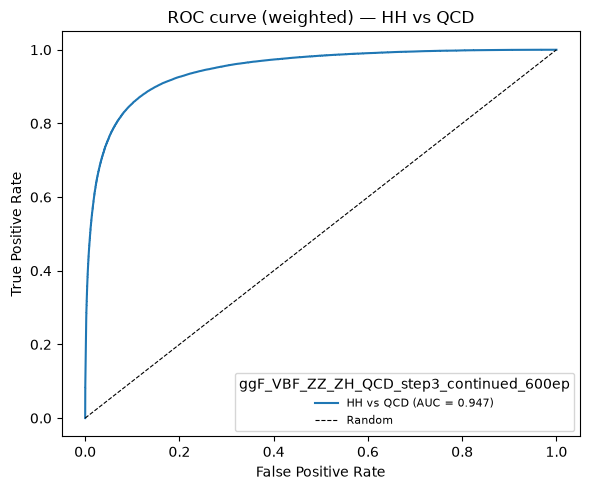

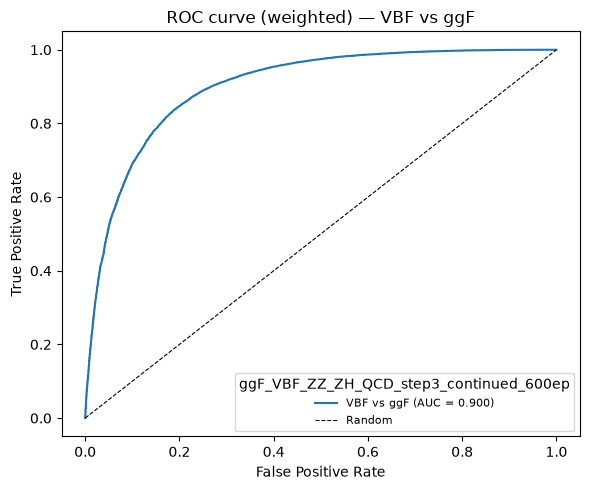

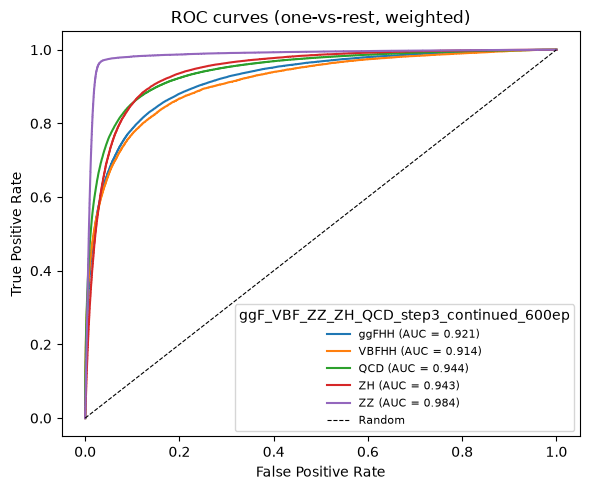

In [6]:

for training in data:
    if data[training].get("MERGE_MAP", False):
        # OvR ROC curves for merged classes (ggF+VBF → HH)
        scores_merged = np.stack([
            data[training]["y_pred_probs"][:, 0] + data[training]["y_pred_probs"][:, 1],  # HH
            data[training]["y_pred_probs"][:, 2],                                           # ZH
            data[training]["y_pred_probs"][:, 3],                                           # ZZ
            data[training]["y_pred_probs"][:, 4],                                           # QCD
        ], axis=1)
        roc_data = []
        for class_idx, class_name in enumerate(data[training]["CLASS_NAMES_MERGED"]):
            y_true_bin = (data[training]["y_true_merged"] == class_idx).astype(int)
            fpr, tpr, _ = roc_curve(y_true_bin, scores_merged[:, class_idx], sample_weight=data[training]["weight"])
            roc_data.append((fpr, tpr, auc(fpr, tpr), class_name))
        plot_roc(roc_data, "ROC curves (one-vs-rest, weighted) — HH merged",
                f"{training}_roc_HH_merged.png",
                training)

    elif data[training].get("HHvsQCD", False):
        # Binary ROC: HH (pos_label=0) vs QCD
        fpr, tpr, _ = roc_curve(
            data[training]["y_true_HHvsQCD"],
            data[training]["score_HHvsQCD"],
            pos_label=0,
            sample_weight=data[training]["weight_HHvsQCD"],
        )
        plot_roc([(fpr, tpr, auc(fpr, tpr), "HH vs QCD")],
                "ROC curve (weighted) — HH vs QCD",
                f"{training}_roc_HH_vs_QCD.png",
                training)

    if data[training].get("VBFvsggF", False):
        # Binary ROC: HH (pos_label=0) vs QCD
        fpr, tpr, _ = roc_curve(
            data[training]["y_true_VBFvsggF"],
            data[training]["score_VBFvsggF"],
            pos_label=0,
            sample_weight=data[training]["weight_VBFvsggF"],
        )
        plot_roc([(fpr, tpr, auc(fpr, tpr), "VBF vs ggF")],
                "ROC curve (weighted) — VBF vs ggF",
                f"{training}_roc_VBF_vs_ggF.png",
                training)

    # Always plot the full multi-class OvR ROC
    roc_data = []
    for class_idx, class_name in enumerate(data[training]["CLASS_NAMES"]):
        y_true_bin = (data[training]["y_true"] == class_idx).astype(int)
        fpr, tpr, _ = roc_curve(y_true_bin, data[training]["y_pred_probs"][:, class_idx], sample_weight=data[training]["weight"])
        roc_data.append((fpr, tpr, auc(fpr, tpr), class_name))
    plot_roc(roc_data, "ROC curves (one-vs-rest, weighted)", f"{training}_roc.png", training)

saved HH_ZZ_ZH_QCD_confusion_matrix_normalized_HH_merged.png
saved HH_ZZ_ZH_QCD_confusion_matrix_counts_HH_merged.png
saved HH_ZZ_ZH_QCD_confusion_matrix_normalized.png
weighted accuracy: 0.7226
saved HH_QCD_confusion_matrix_normalized.png
weighted accuracy: 0.8764
saved HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continued_confusion_matrix_normalized_HH_vs_QCD.png
saved HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continued_confusion_matrix_normalized.png
weighted accuracy: 0.7958
saved HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued_2_confusion_matrix_normalized_HH_vs_QCD.png
saved HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued_2_confusion_matrix_normalized.png
weighted accuracy: 0.7736
saved ggF_VBF_ZZ_ZH_QCD_step3_confusion_matrix_normalized_HH_vs_QCD.png
saved ggF_VBF_ZZ_ZH_QCD_step3_confusion_matrix_normalized.png
weighted accuracy: 0.7535
saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600ep_confusion_matrix_normalized_HH_vs_QCD.png
saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600ep_confusion_matrix_normalized.png
weighted accuracy: 0.751

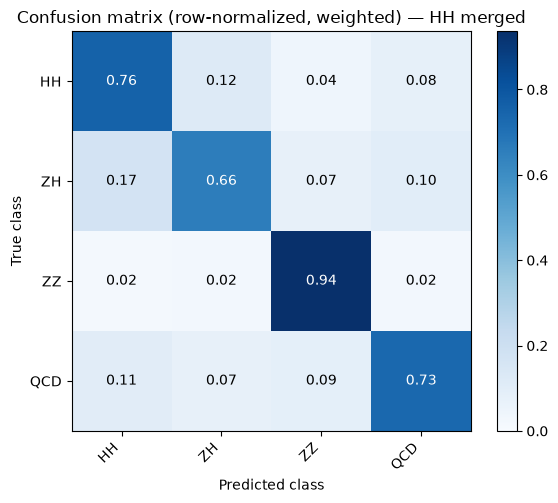

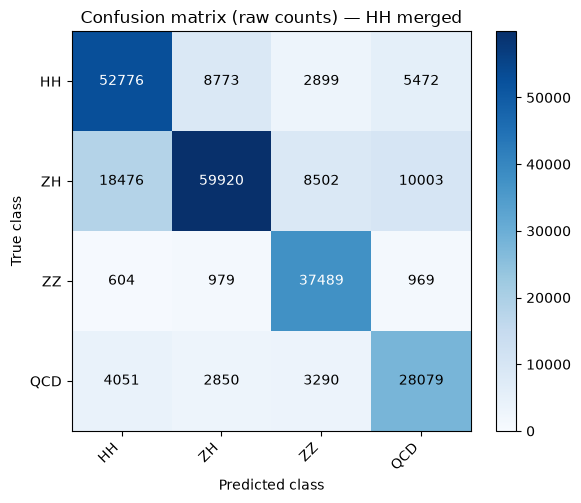

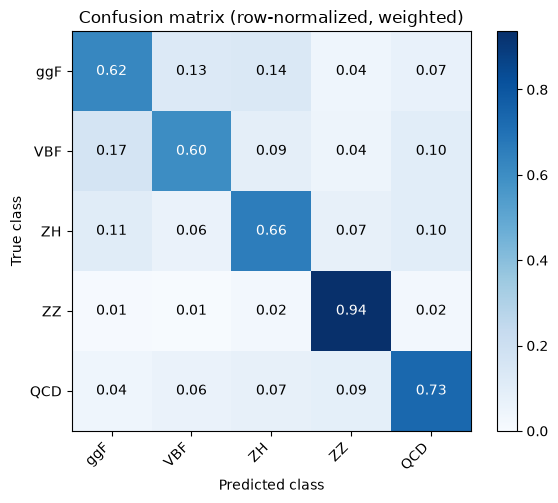

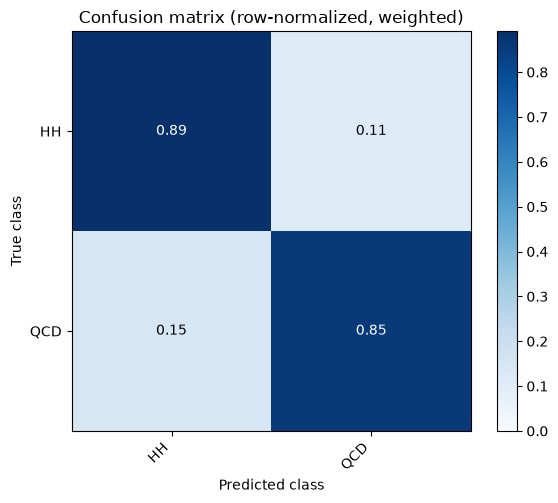

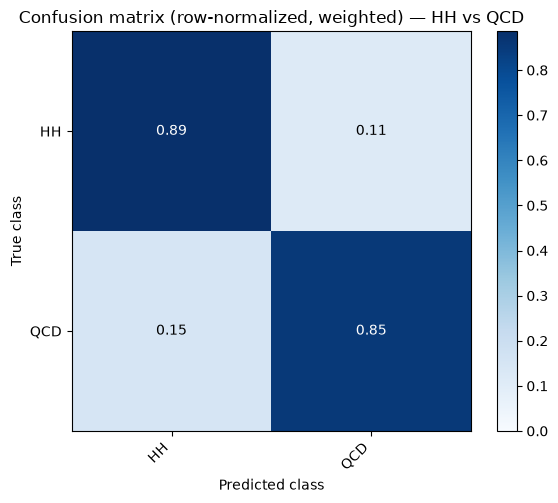

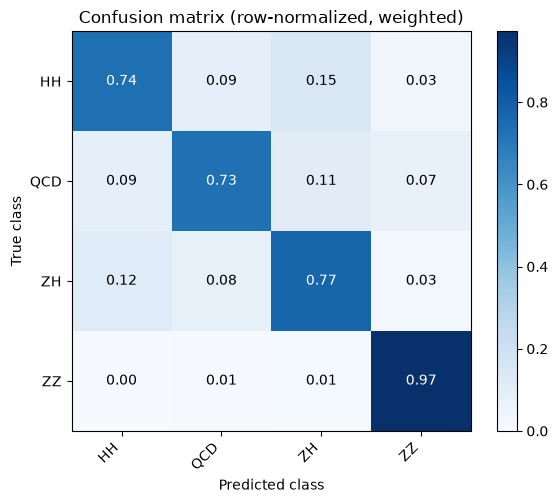

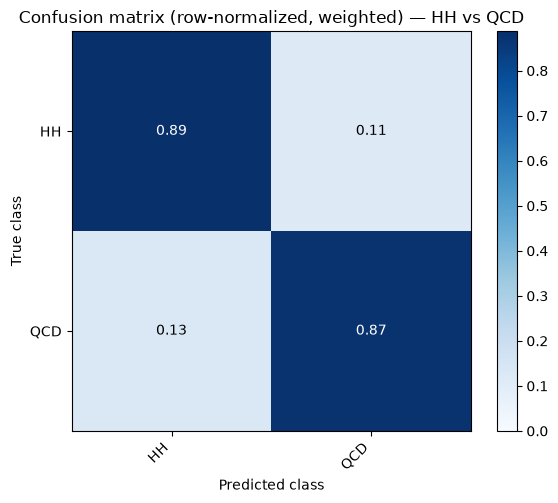

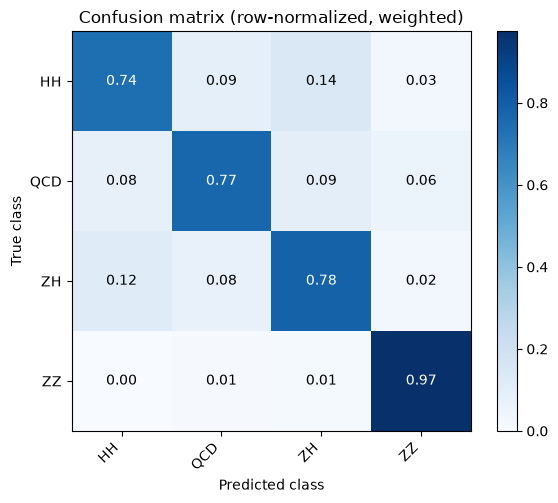

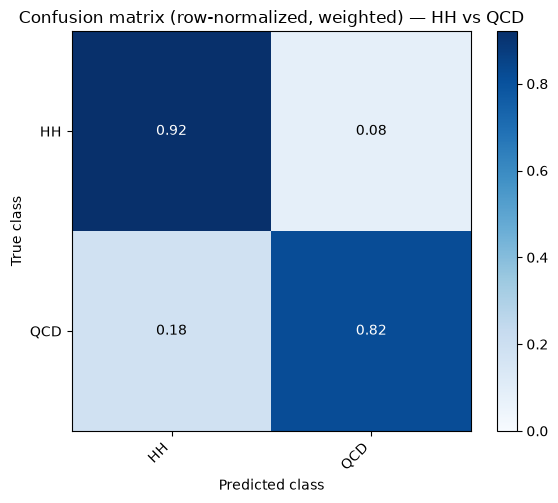

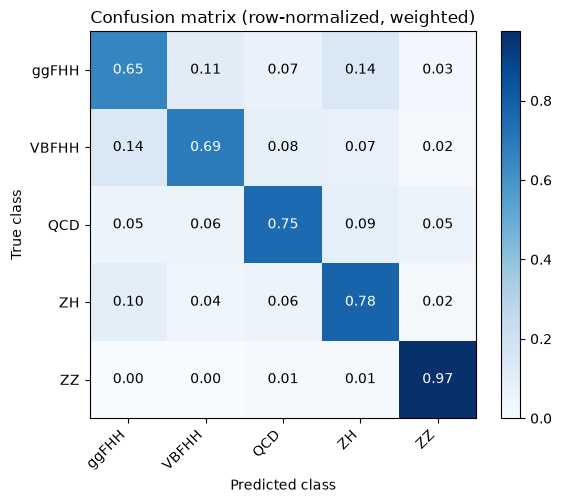

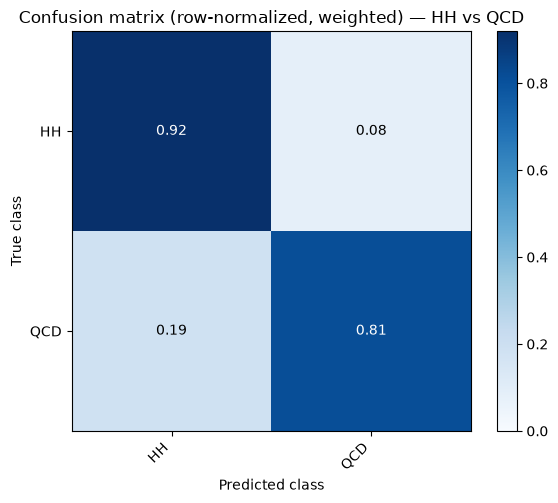

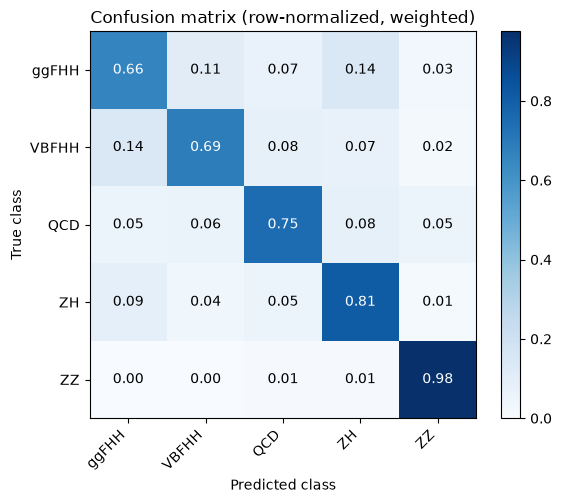

In [7]:
for training in data:
    if data[training].get("MERGE_MAP", False):
        merged = "_merged"
        MERGED = "_MERGED"
            # ── merged: ggF + VBF → HH ────────────────────────────────────────────────────
        cm_norm_merged = confusion_matrix(
            data[training][f"y_true{merged}"], data[training][f"y_pred{merged}"], labels=data[training][f"labels{merged}"], sample_weight=data[training]["weight"], normalize="true"
        )
        plot_confusion(cm_norm_merged, data[training][f"CLASS_NAMES{MERGED}"],
                    "Confusion matrix (row-normalized, weighted) — HH merged",
                    f"{training}_confusion_matrix_normalized_HH_merged.png")

        cm_counts_merged = confusion_matrix(data[training][f"y_true{merged}"], data[training][f"y_pred{merged}"], labels=data[training][f"labels{merged}"])
        plot_confusion(cm_counts_merged,  data[training][f"CLASS_NAMES{MERGED}"],
                    "Confusion matrix (raw counts) — HH merged",
                    f"{training}_confusion_matrix_counts_HH_merged.png", fmt="d")
        
    elif data[training].get("HHvsQCD", False):
        merged = "_HHvsQCD"
        MERGED = "_HHvsQCD"
            # ── merged: ggF + VBF → HH ────────────────────────────────────────────────────
        cm_norm_merged = confusion_matrix(
            data[training][f"y_true{merged}"], data[training][f"y_pred{merged}"], labels=data[training][f"labels{merged}"], sample_weight=data[training][f"weight{merged}"], normalize="true"
        )
        plot_confusion(cm_norm_merged, data[training][f"CLASS_NAMES{MERGED}"],
                    "Confusion matrix (row-normalized, weighted) — HH vs QCD",
                    f"{training}_confusion_matrix_normalized_HH_vs_QCD.png")

    else:
        merged = "" 
        MERGED = "" 
    # ── merged: ggF + VBF → HH ───────────────────────────────────────────────────

    # ── original: ggF and VBF separate ────────────────────────────────────────────
    cm_norm = confusion_matrix(data[training]["y_true"], data[training]["y_pred"], labels=data[training]["labels"], sample_weight=data[training]["weight"], normalize="true")
    plot_confusion(cm_norm, data[training]["CLASS_NAMES"],
                "Confusion matrix (row-normalized, weighted)",
                f"{training}_confusion_matrix_normalized.png")

    # cm_counts = confusion_matrix(data[training]["y_true"], data[training]["y_pred"], labels=data[training]["labels"])
    # plot_confusion(cm_counts, data[training]["CLASS_NAMES"],
    #             "Confusion matrix (raw counts)",
    #             f"{training}_confusion_matrix_counts.png", fmt="d")

    overall_acc = np.average(data[training]["y_true"] == data[training]["y_pred"], weights=data[training]["weight"] )
    print(f"weighted accuracy: {overall_acc:.4f}")

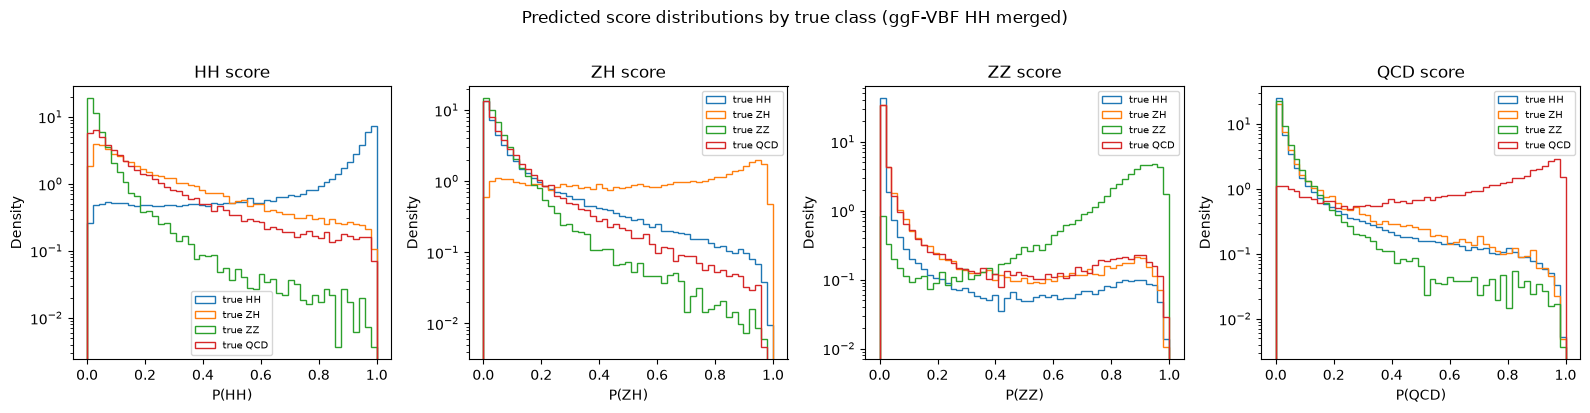

saved HH_ZZ_ZH_QCD_score_distributions_HH_merged_log.png


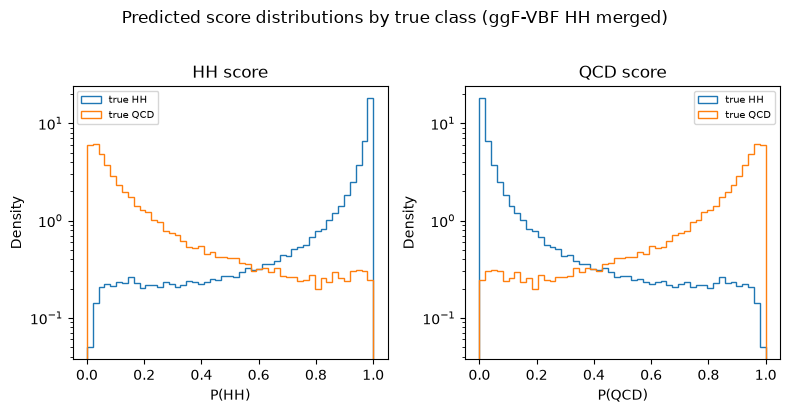

saved HH_QCD_score_distributions_HH_log.png


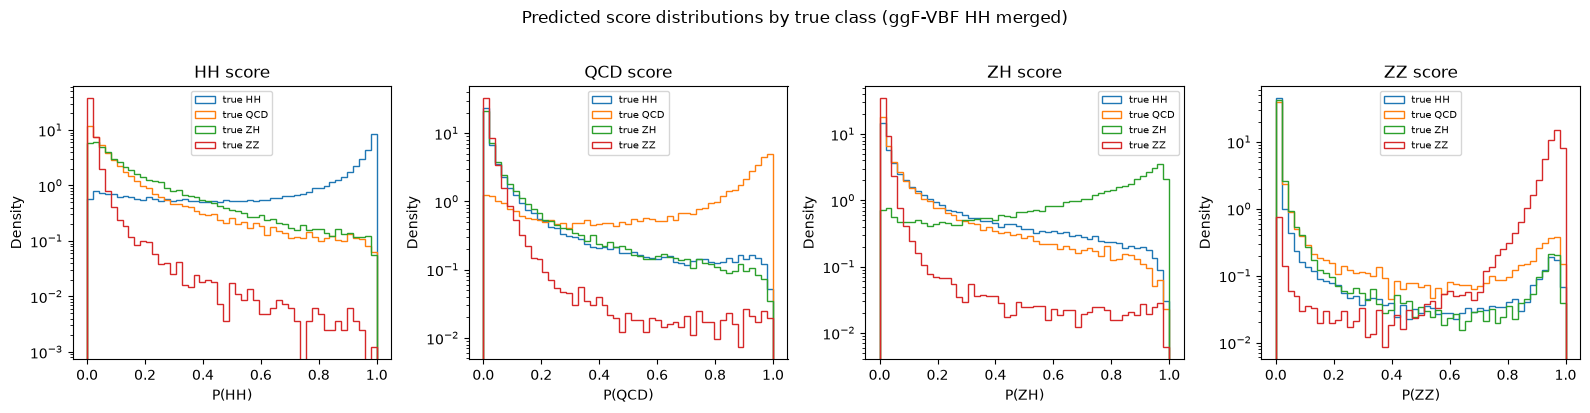

saved HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continued_score_distributions_HH_log.png


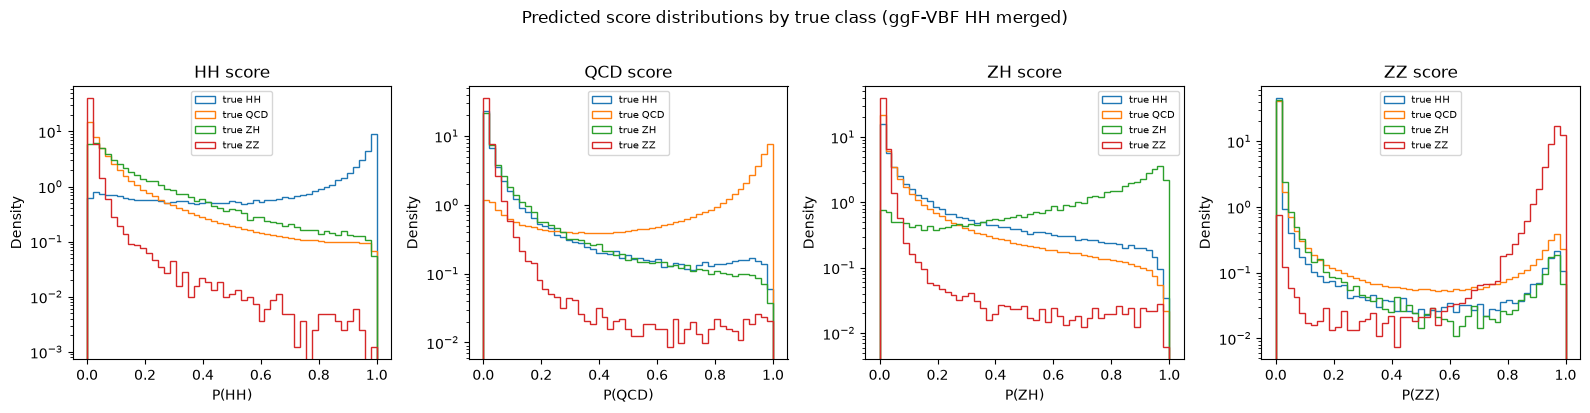

saved HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued_2_score_distributions_HH_log.png


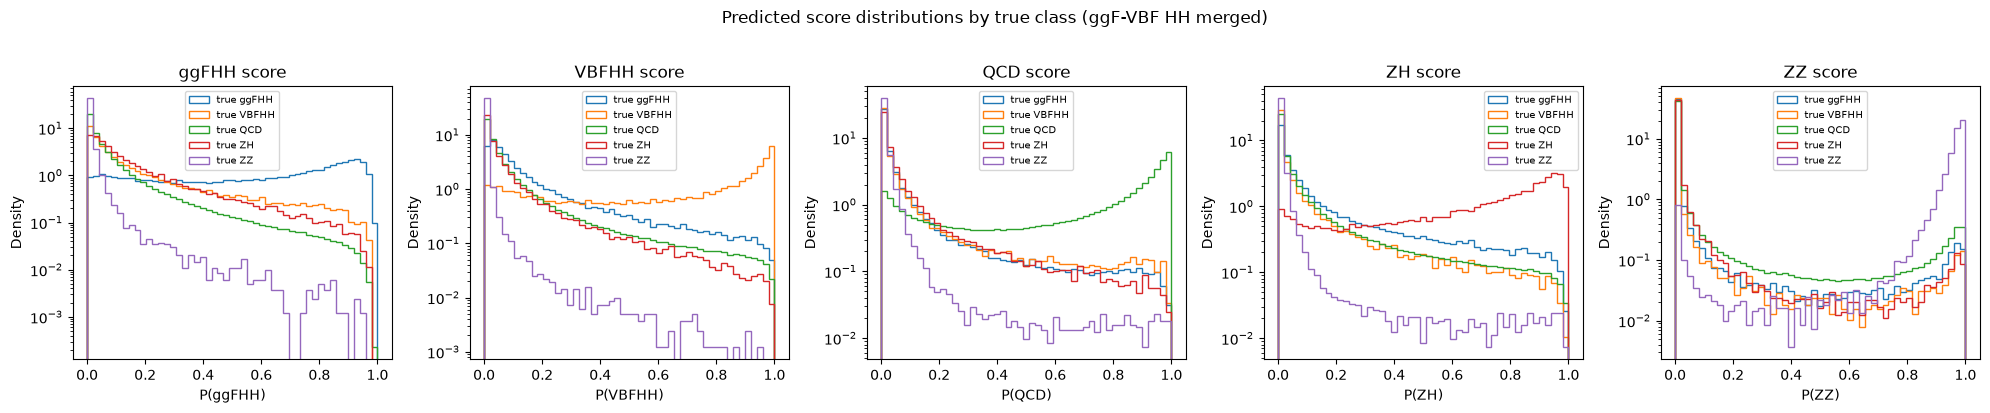

saved ggF_VBF_ZZ_ZH_QCD_step3_score_distributions_HH_log.png


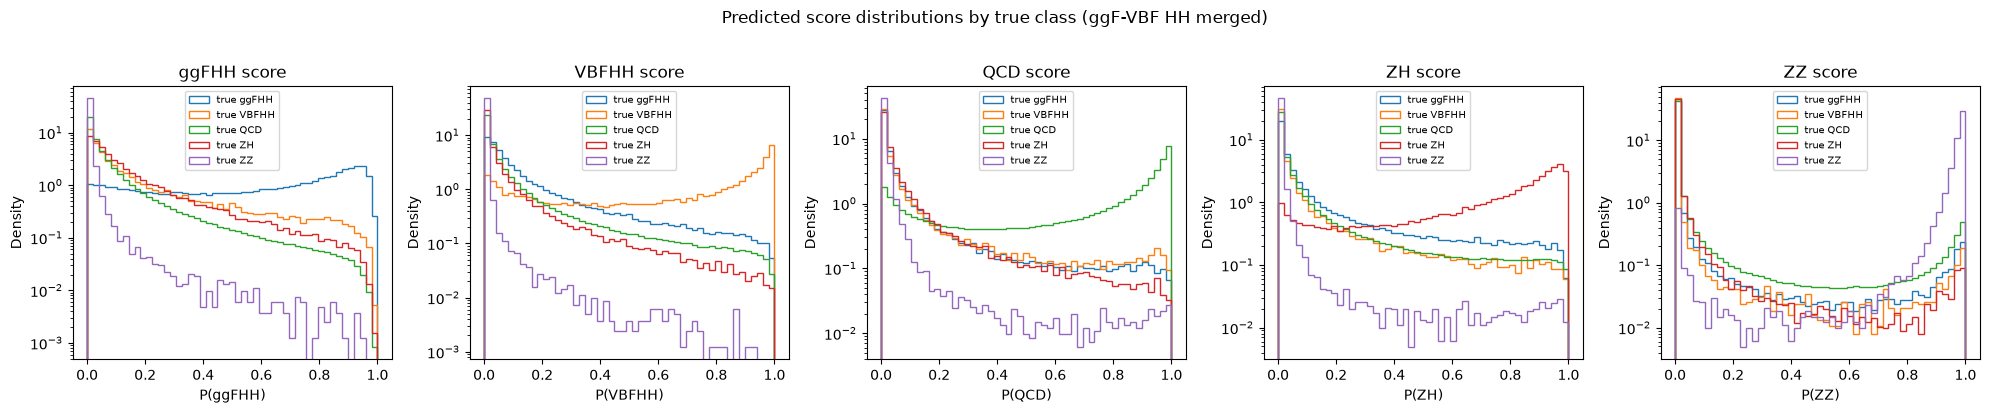

saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600ep_score_distributions_HH_log.png


In [8]:
LOG = True 
for training in data:
    if data[training].get("MERGE_MAP", False):# Merged class scores: HH = P(ggF) + P(VBF), others as-is
        data[training]["scores_merged"] = np.stack([
            data[training]["y_pred_probs"][:, 0] + data[training]["y_pred_probs"][:, 1],  # HH
            data[training]["y_pred_probs"][:, 2],                         # ZH
            data[training]["y_pred_probs"][:, 3],                         # ZZ
            data[training]["y_pred_probs"][:, 4],                         # QCD
        ], axis=1)

        merged = "_merged"
        MERGED = "_MERGED"

    else:
        merged = "" 
        MERGED = ""
        data[training]["scores"] = np.stack([data[training]["y_pred_probs"][:, i] for i in range(len(data[training]["CLASS_NAMES"]))], axis=1)
    
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
    bins = np.linspace(0, 1, 50)
    
    fig, axes = plt.subplots(1, len(data[training][f"CLASS_NAMES{MERGED}"]), figsize=(4 * len(data[training][f"CLASS_NAMES{MERGED}"]), 4), sharey=False)
    
    for col_idx, (score_name, ax, color) in enumerate(zip(data[training][f"CLASS_NAMES{MERGED}"], axes, colors)):
        for true_idx, true_name in enumerate(data[training][f"CLASS_NAMES{MERGED}"]):
            mask = data[training][f"y_true{merged}"] == true_idx
            ax.hist(
                data[training][f"scores{merged}"][mask, col_idx],
                bins=bins,
                weights=data[training]["weight"][mask],
                histtype="step",
                label=f"true {true_name}",
                density=True,
            )
        ax.set_xlabel(f"P({score_name})")
        ax.set_ylabel("Density")
        ax.set_title(f"{score_name} score")
        ax.legend(fontsize=7)

        if LOG:
            ax.set_yscale("log")
            log = "_log"
        else:
            log = ""
    
    fig.suptitle("Predicted score distributions by true class (ggF-VBF HH merged)", y=1.02)
    fig.tight_layout()
    fig.savefig(f"{training}_score_distributions_HH{merged}{log}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {training}_score_distributions_HH{merged}{log}.png")

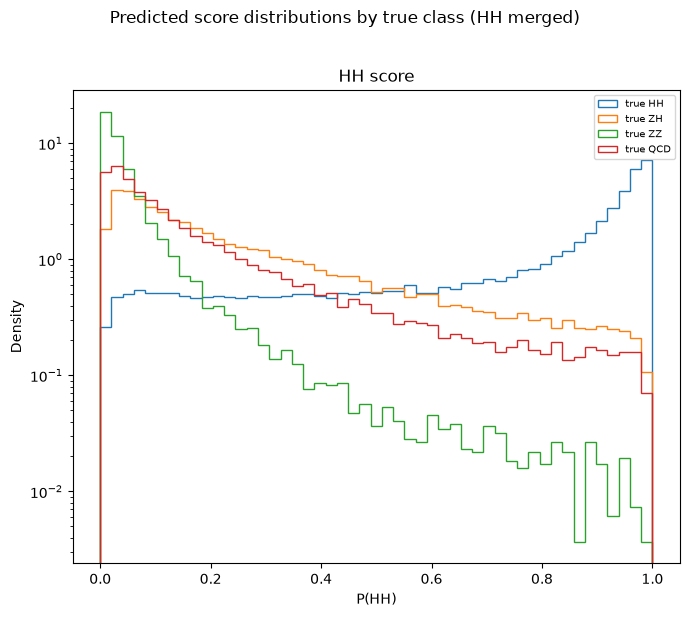

saved HH_ZZ_ZH_QCDscore_distributions_QCD_merged.png


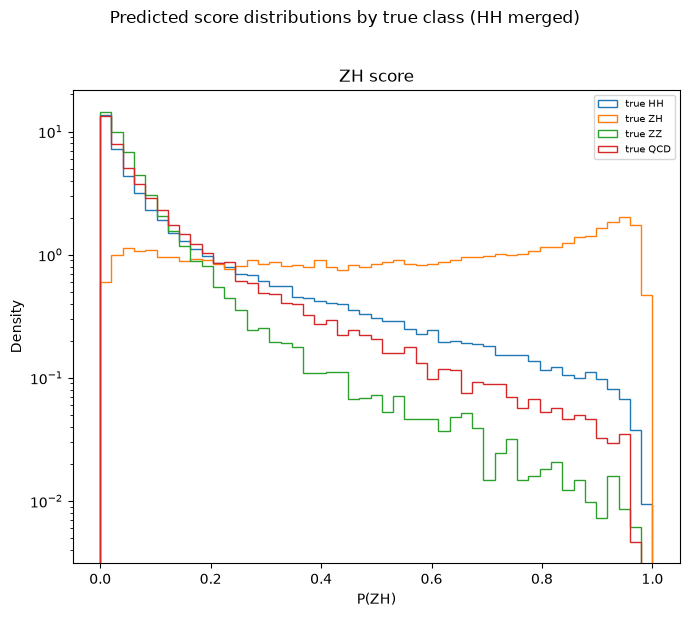

saved HH_ZZ_ZH_QCDscore_distributions_QCD_merged.png


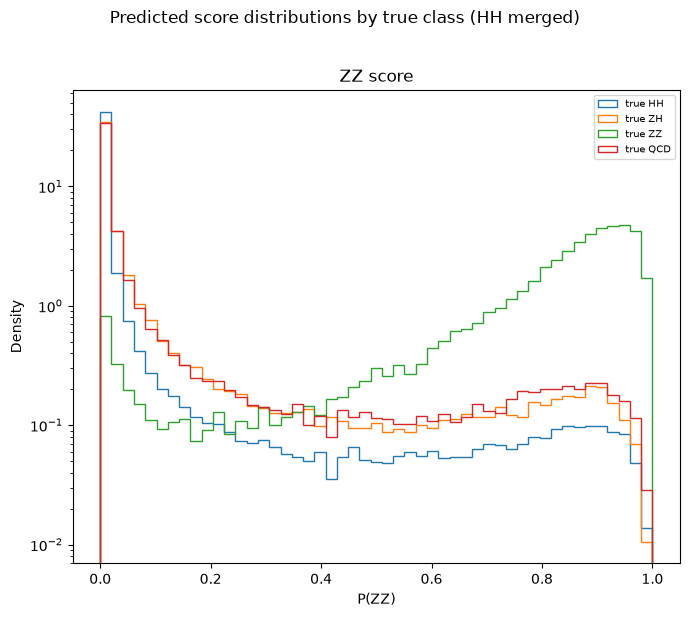

saved HH_ZZ_ZH_QCDscore_distributions_QCD_merged.png


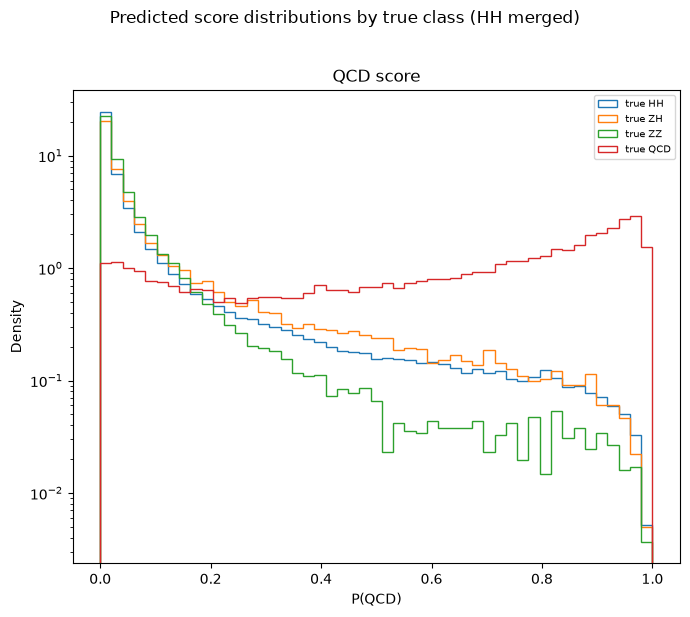

saved HH_ZZ_ZH_QCDscore_distributions_QCD_merged.png


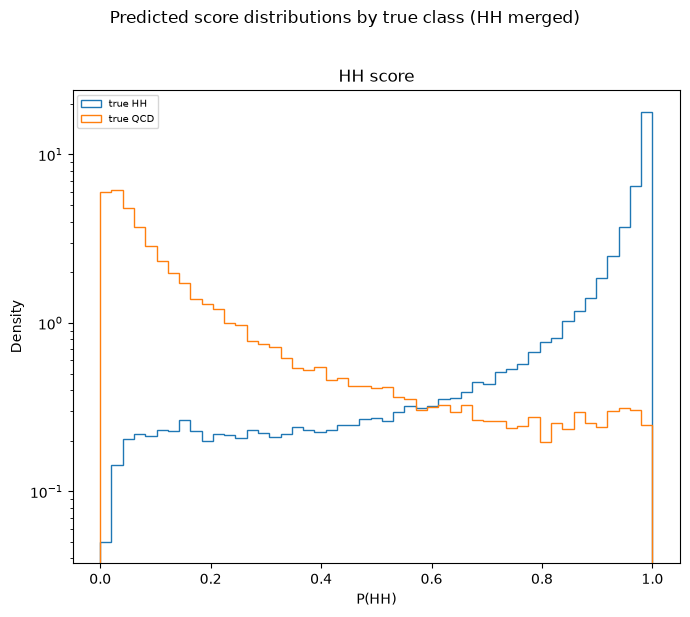

saved HH_QCDscore_distributions_QCD.png


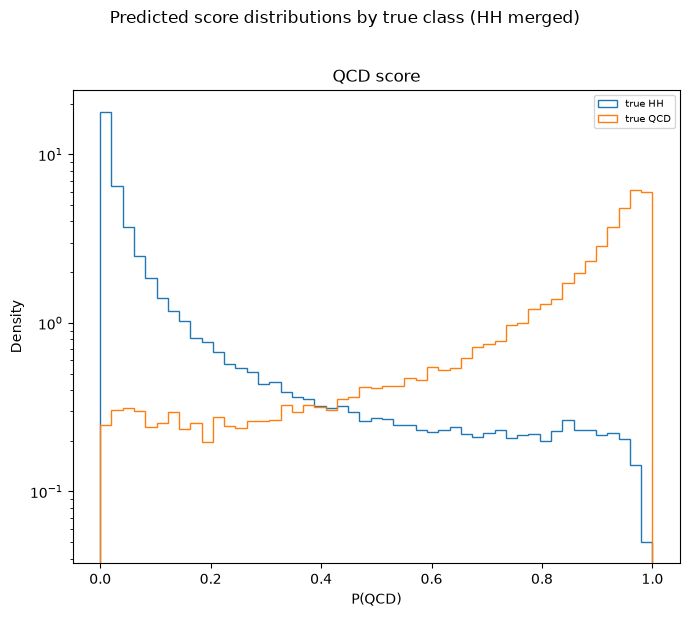

saved HH_QCDscore_distributions_QCD.png


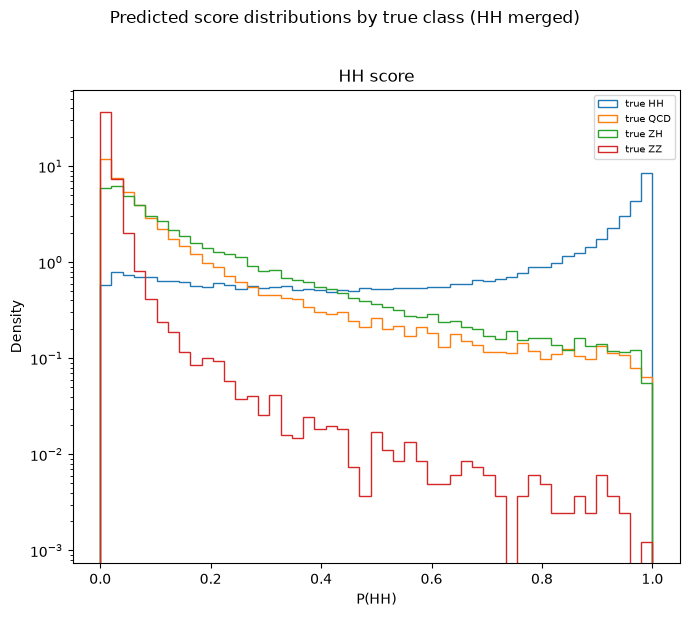

saved HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continuedscore_distributions_ZZ.png


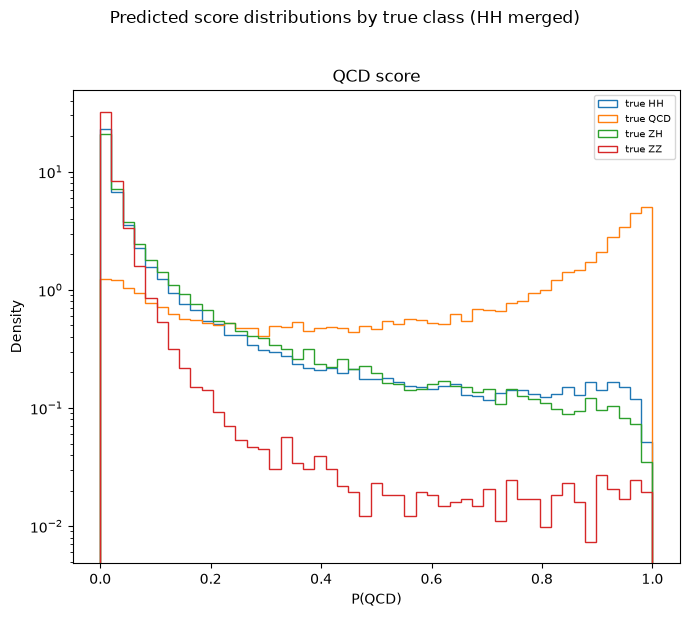

saved HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continuedscore_distributions_ZZ.png


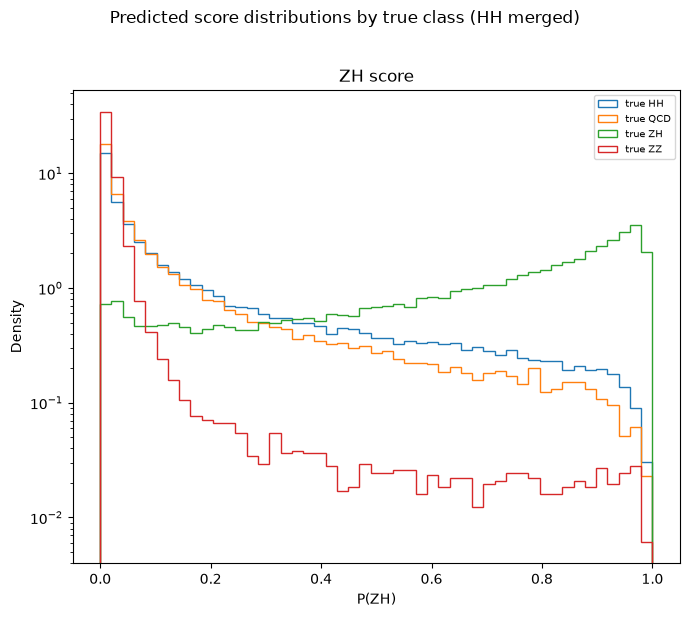

saved HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continuedscore_distributions_ZZ.png


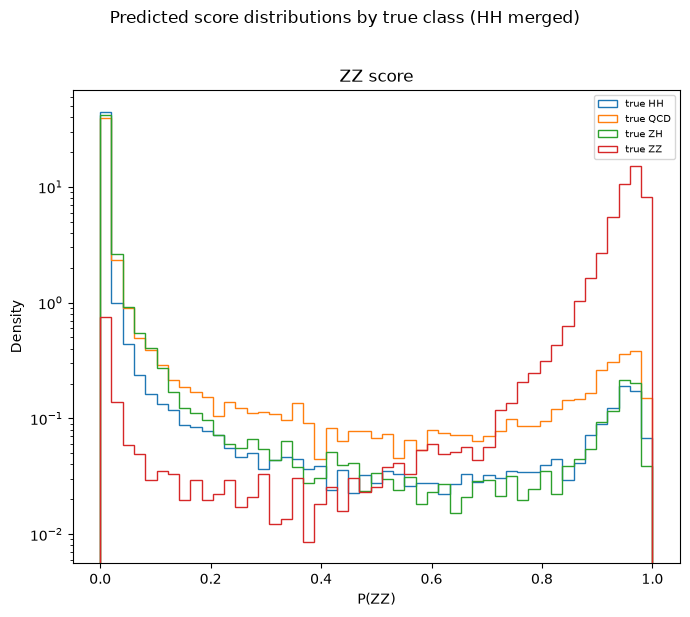

saved HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continuedscore_distributions_ZZ.png


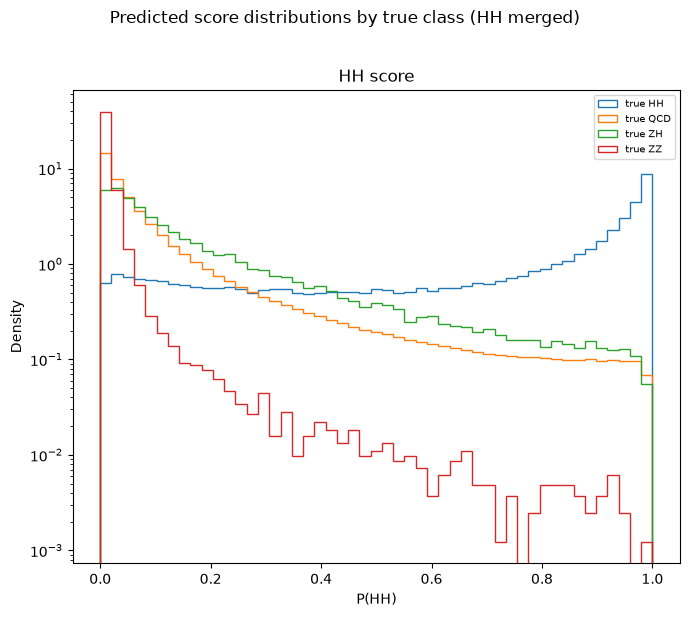

saved HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued_2score_distributions_ZZ.png


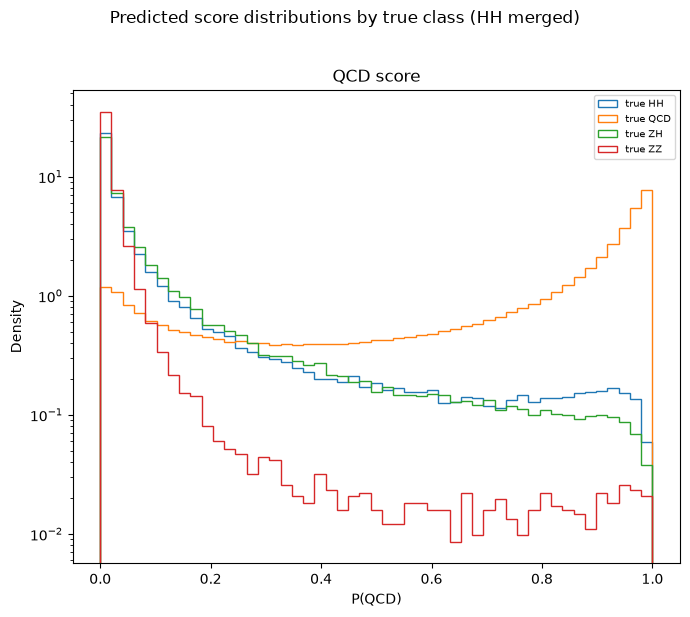

saved HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued_2score_distributions_ZZ.png


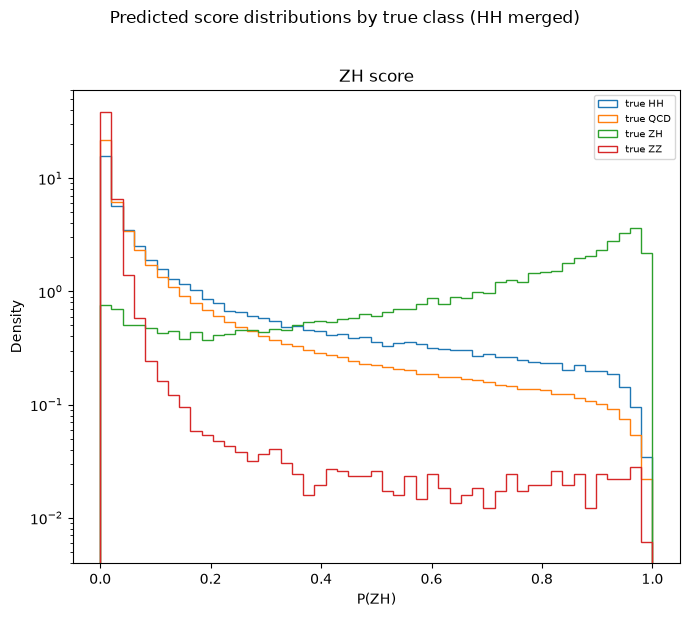

saved HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued_2score_distributions_ZZ.png


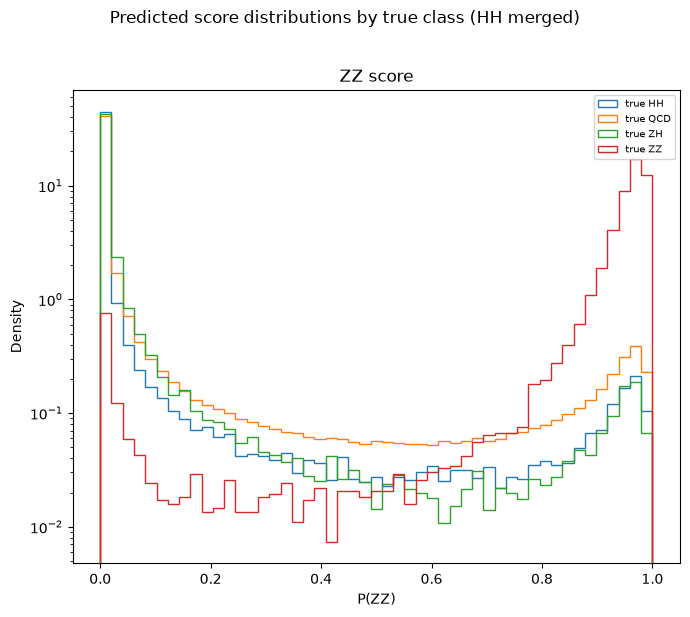

saved HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued_2score_distributions_ZZ.png


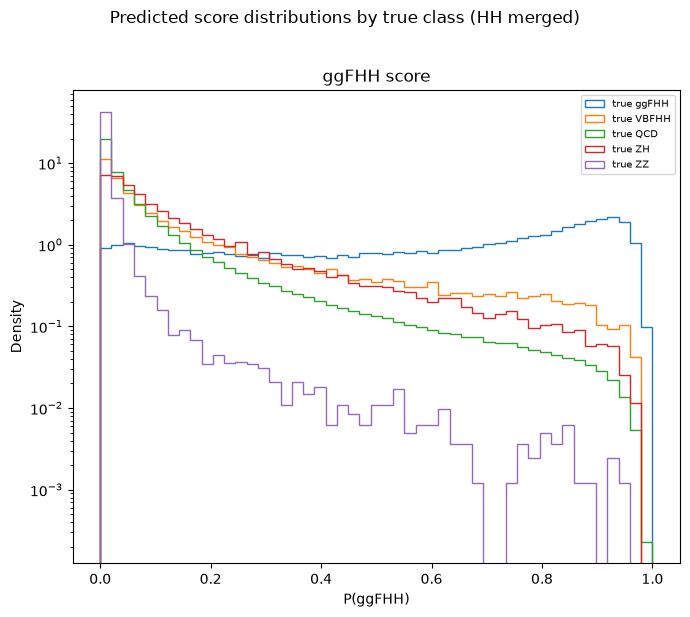

saved ggF_VBF_ZZ_ZH_QCD_step3score_distributions_ZZ.png


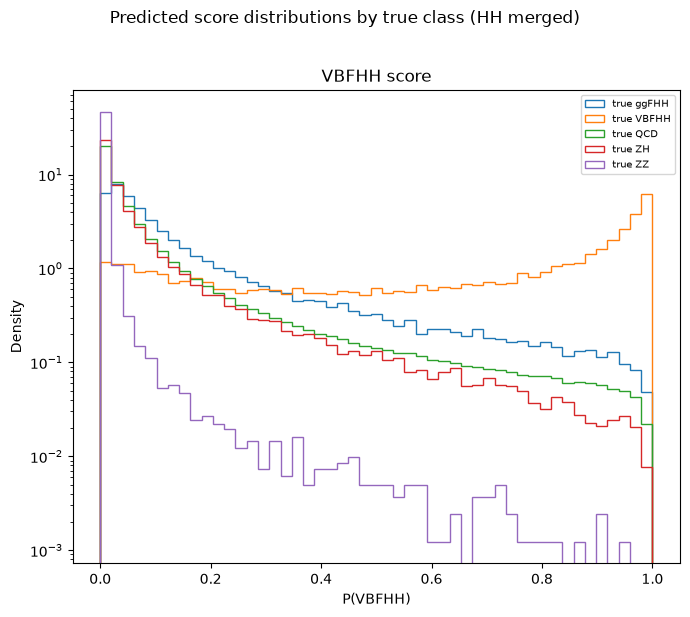

saved ggF_VBF_ZZ_ZH_QCD_step3score_distributions_ZZ.png


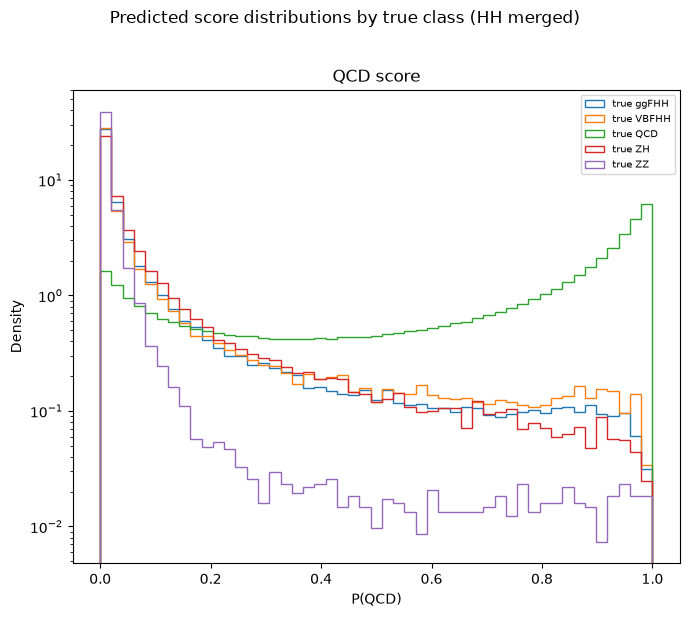

saved ggF_VBF_ZZ_ZH_QCD_step3score_distributions_ZZ.png


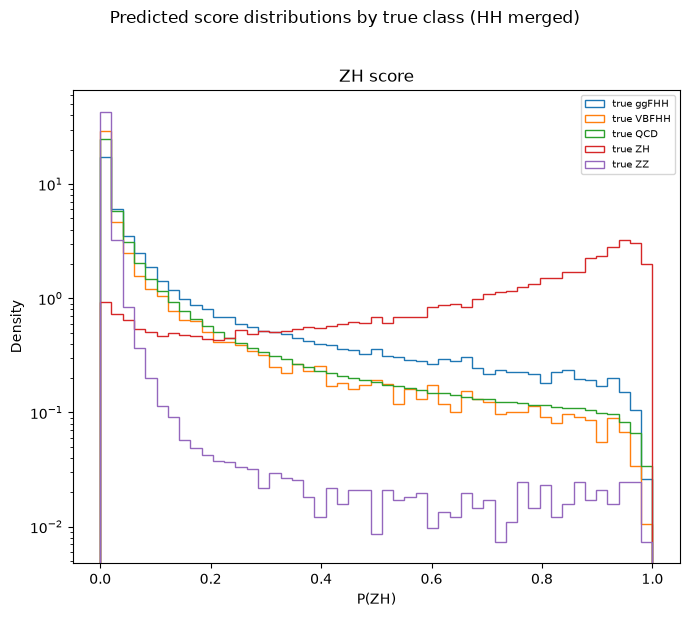

saved ggF_VBF_ZZ_ZH_QCD_step3score_distributions_ZZ.png


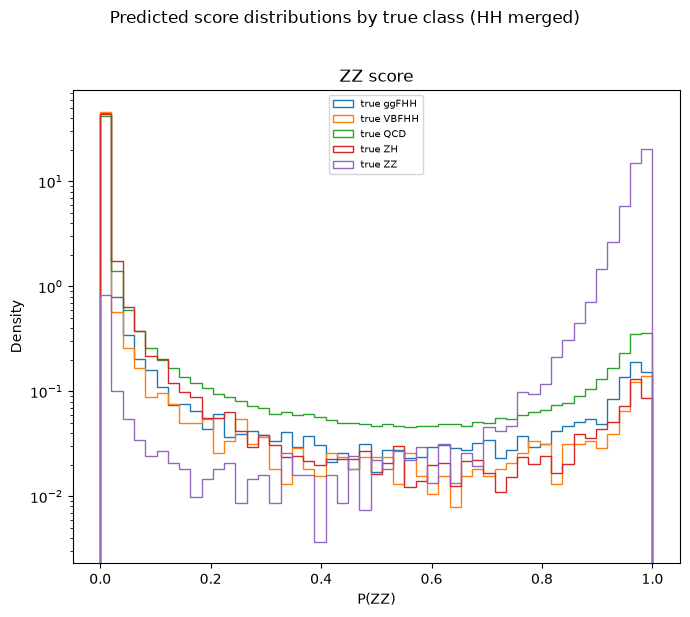

saved ggF_VBF_ZZ_ZH_QCD_step3score_distributions_ZZ.png


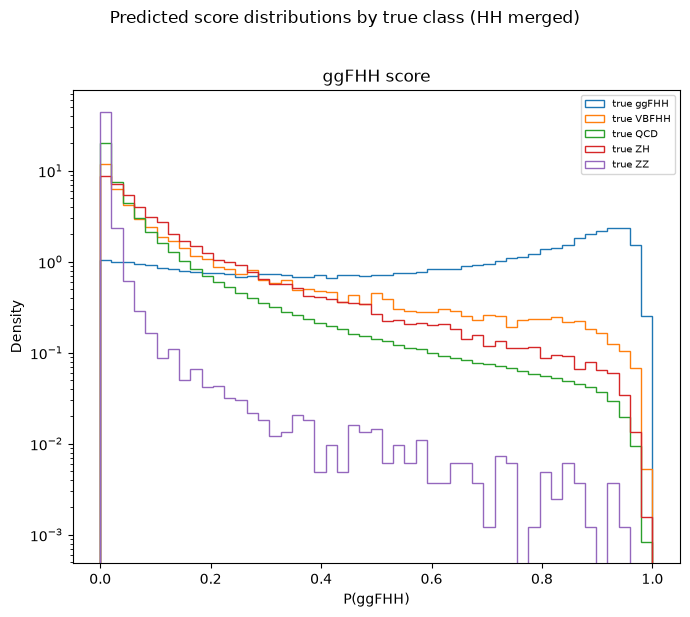

saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600epscore_distributions_ZZ.png


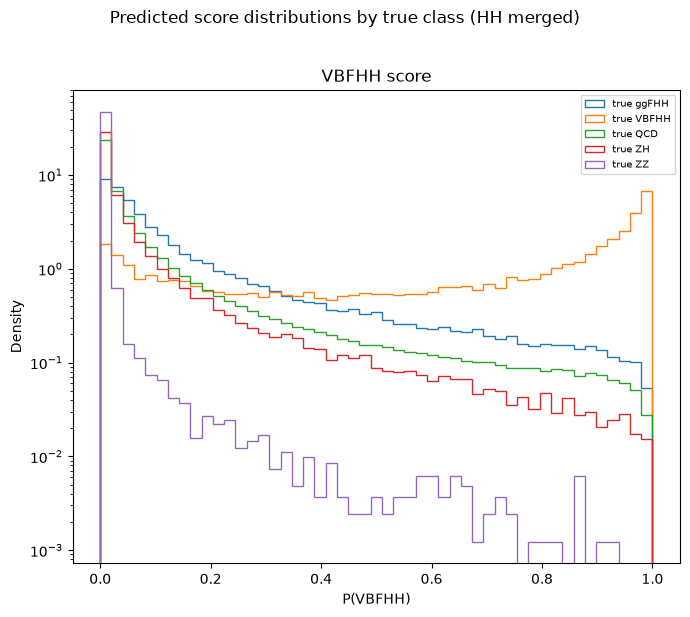

saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600epscore_distributions_ZZ.png


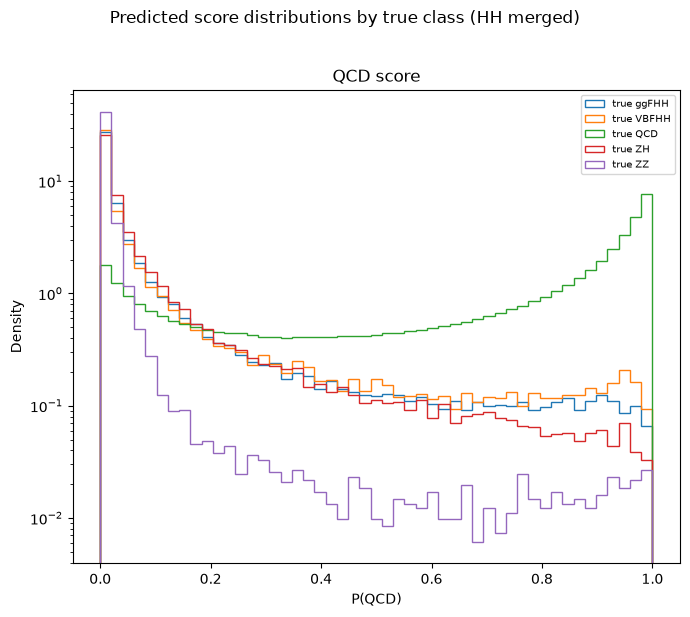

saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600epscore_distributions_ZZ.png


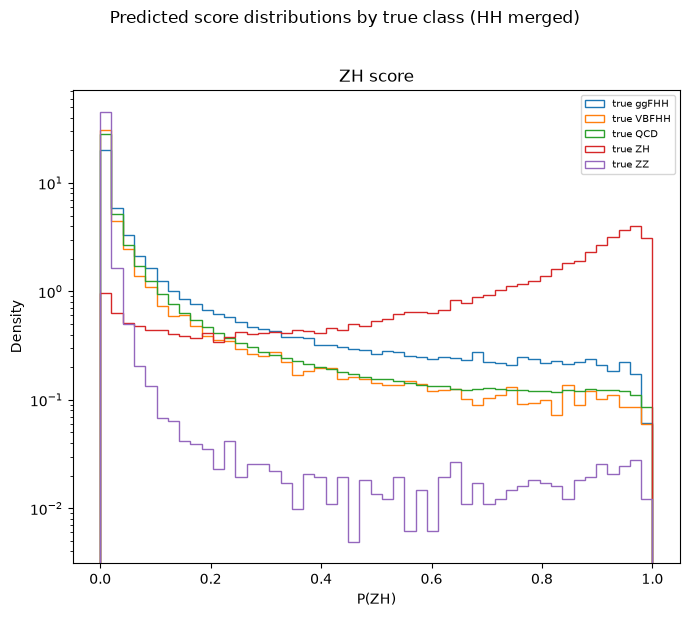

saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600epscore_distributions_ZZ.png


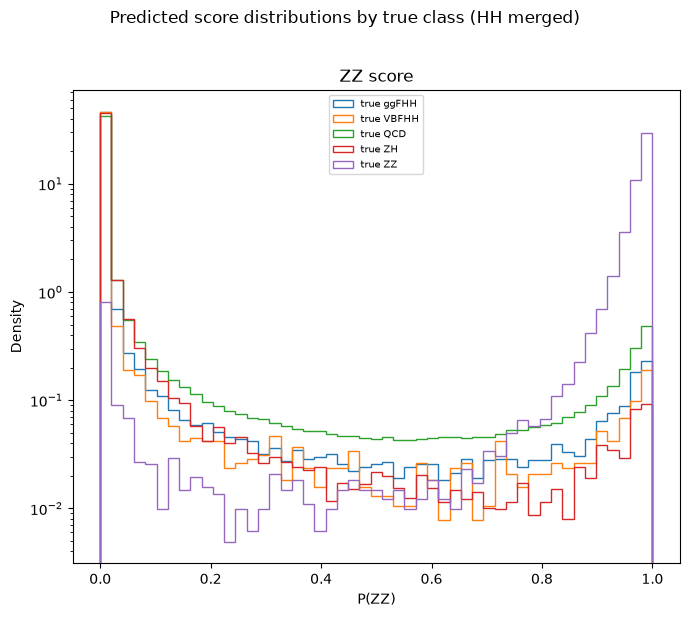

saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600epscore_distributions_ZZ.png


In [9]:
LOG = True  # Set to True to use logarithmic scale for y-axis in score distribution plots
for training in data:
    if data[training].get("MERGE_MAP", False):# Merged class scores: HH = P(ggF) + P(VBF), others as-is
        data[training]["scores_merged"] = np.stack([
            data[training]["y_pred_probs"][:, 0] + data[training]["y_pred_probs"][:, 1],  # HH
            data[training]["y_pred_probs"][:, 2],                         # ZH
            data[training]["y_pred_probs"][:, 3],                         # ZZ
            data[training]["y_pred_probs"][:, 4],                         # QCD
        ], axis=1)

        merged = "_merged"
        MERGED = "_MERGED"

    else:
        merged = "" 
        MERGED = ""
        data[training]["scores"] = np.stack([data[training]["y_pred_probs"][:, i] for i in range(len(data[training]["CLASS_NAMES"]))], axis=1)

    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    bins = np.linspace(0, 1, 50)
    
    for col_idx, (score_name, color) in enumerate(zip(data[training][f"CLASS_NAMES{MERGED}"], colors)):
        fig, ax = plt.subplots(1, 1, figsize=(7, 6), sharey=False)
        for true_idx, true_name in enumerate(data[training][f"CLASS_NAMES{MERGED}"]):
            mask = data[training][f"y_true{merged}"] == true_idx
            ax.hist(
                data[training][f"scores{merged}"][mask, col_idx],
                bins=bins,
                weights=data[training]["weight"][mask],
                histtype="step",
                label=f"true {true_name}",
                density=True,
            )
        ax.set_xlabel(f"P({score_name})")
        ax.set_ylabel("Density")
        if LOG:
            ax.set_yscale("log")
            log = "_log"
        else:
            log = ""
        ax.set_title(f"{score_name} score")
        ax.legend(fontsize=7)
    
        fig.suptitle("Predicted score distributions by true class (HH merged)", y=1.02)
        fig.tight_layout()
        fig.savefig(f"{training}score_distributions_{true_name}{merged}{log}.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"saved {training}score_distributions_{true_name}{merged}.png")

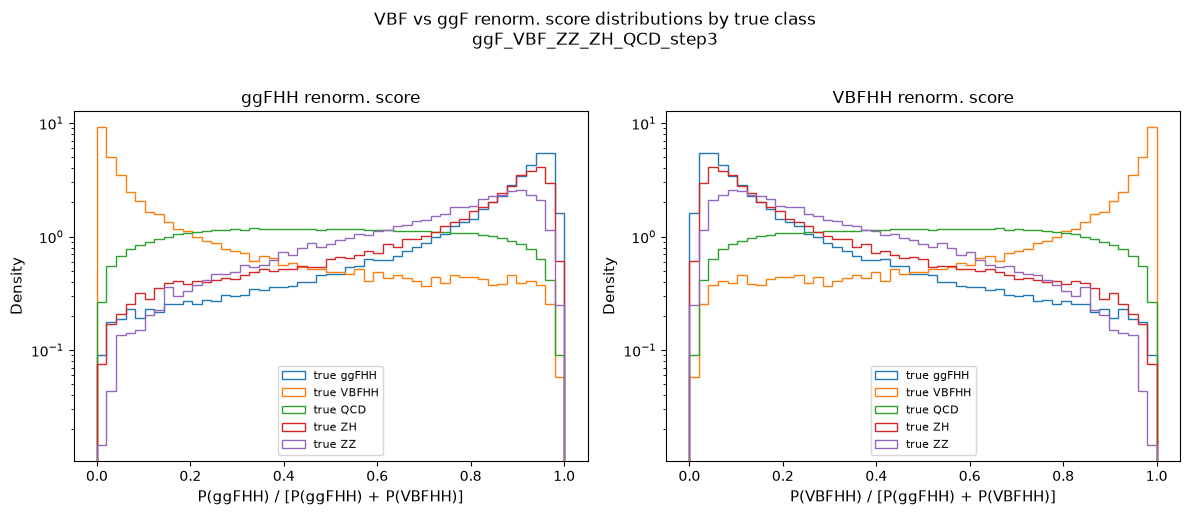

saved ggF_VBF_ZZ_ZH_QCD_step3_score_distributions_VBFvsggF_log.png


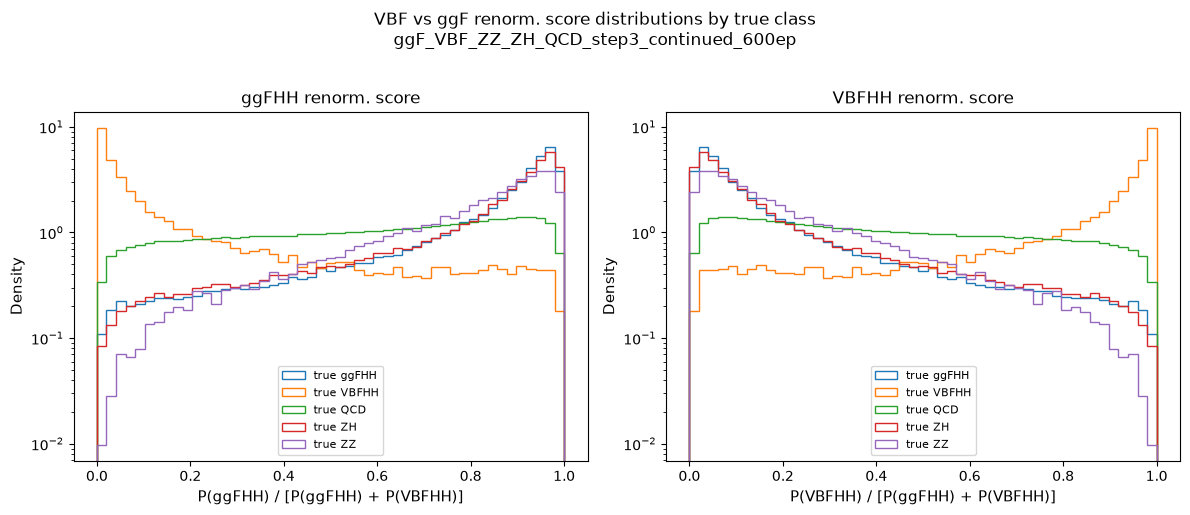

saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600ep_score_distributions_VBFvsggF_log.png


In [10]:
LOG = True  # log scale on y-axis

for training in data:
    if not data[training].get("VBFvsggF", False):
        continue

    cnames    = data[training]["CLASS_NAMES"]                            # original classes (for true-label loop)
    vbf_names = data[training].get("CLASS_NAMES_VBFvsggF", ["ggFHH", "VBFHH"])
    # y_pred_probs_VBFvsggF is the full (unmasked) renorm array: [P(ggFHH), P(VBFHH)] / (P(ggFHH)+P(VBFHH))
    scores_vbf = data[training]["y_pred_probs_VBFvsggF"]                 # shape (N, 2)
    y_true     = data[training]["y_true"]
    weights    = data[training]["weight"]

    bins   = np.linspace(0, 1, 50)
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for col_idx, (score_name, ax) in enumerate(zip(vbf_names, axes)):
        for true_idx, true_name in enumerate(cnames):
            mask = y_true == true_idx
            ax.hist(
                scores_vbf[mask, col_idx],
                bins=bins,
                weights=weights[mask],
                histtype="step",
                color=colors[true_idx % len(colors)],
                label=f"true {true_name}",
                density=True,
            )
        ax.set_xlabel(f"P({score_name}) / [P(ggFHH) + P(VBFHH)]", fontsize=11)
        ax.set_ylabel("Density", fontsize=11)
        ax.set_title(f"{score_name} renorm. score", fontsize=12)
        ax.legend(fontsize=8)
        if LOG:
            ax.set_yscale("log")

    log = "_log" if LOG else ""
    fig.suptitle(f"VBF vs ggF renorm. score distributions by true class\n{training}", y=1.02)
    fig.tight_layout()
    fname = f"{training}_score_distributions_VBFvsggF{log}.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {fname}")


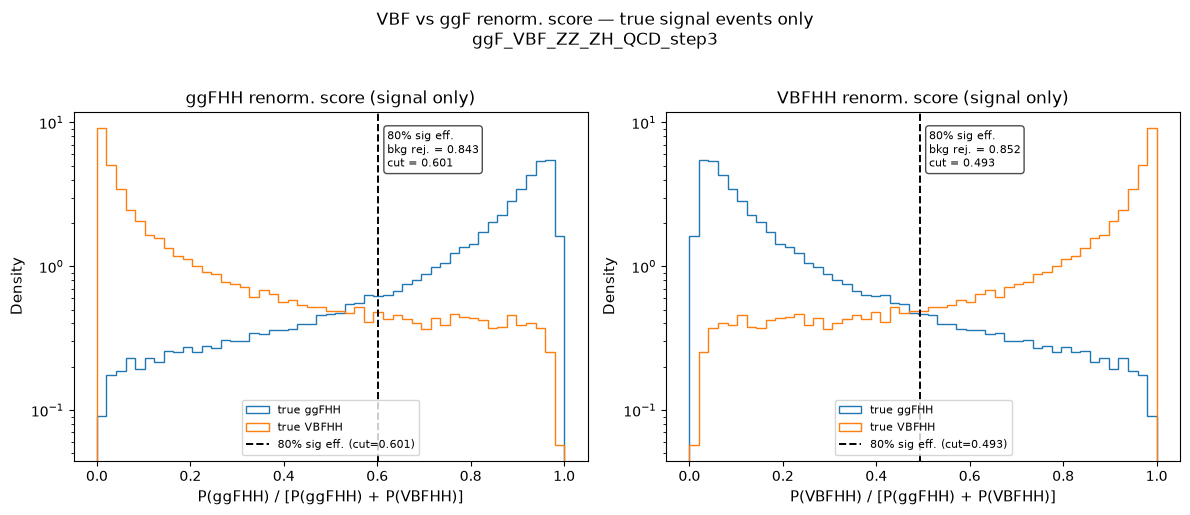

saved ggF_VBF_ZZ_ZH_QCD_step3_score_distributions_VBFvsggF_sigonly_log.png
  [ggF_VBF_ZZ_ZH_QCD_step3] 80% signal efficiency working points:
    targeting ggFHH   : score cut = 0.6013,  bkg rej. = 0.8434  (80% ggFHH efficiency)
    targeting VBFHH   : score cut = 0.4928,  bkg rej. = 0.8522  (80% VBFHH efficiency)


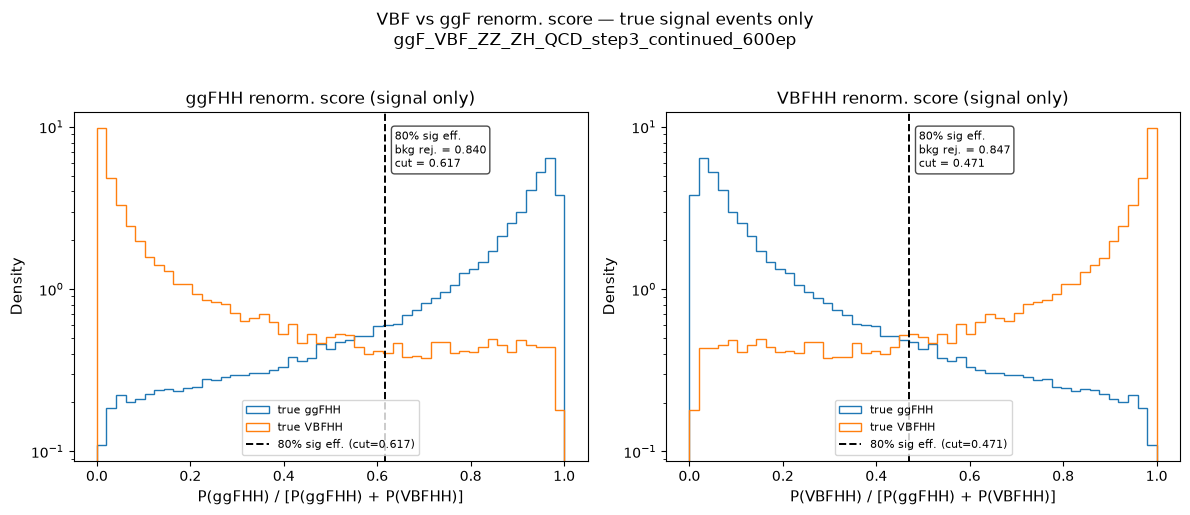

saved ggF_VBF_ZZ_ZH_QCD_step3_continued_600ep_score_distributions_VBFvsggF_sigonly_log.png
  [ggF_VBF_ZZ_ZH_QCD_step3_continued_600ep] 80% signal efficiency working points:
    targeting ggFHH   : score cut = 0.6174,  bkg rej. = 0.8397  (80% ggFHH efficiency)
    targeting VBFHH   : score cut = 0.4710,  bkg rej. = 0.8469  (80% VBFHH efficiency)


In [18]:
LOG = True   # log scale on y-axis
SIG_EFF = 0.80  # signal efficiency working point

for training in data:
    if not data[training].get("VBFvsggF", False):
        continue

    vbf_names   = data[training].get("CLASS_NAMES_VBFvsggF", ["ggFHH", "VBFHH"])
    sig_mask    = data[training]["y_true"] < 2
    scores_vbf  = data[training]["y_pred_probs_VBFvsggF"][sig_mask]  # shape (N_sig, 2)
    y_true_sig  = data[training]["y_true"][sig_mask]
    weights_sig = data[training]["weight"][sig_mask]

    bins   = np.linspace(0, 1, 50)
    colors = ["tab:blue", "tab:orange"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for col_idx, (score_name, ax) in enumerate(zip(vbf_names, axes)):
        # col_idx=0 → P(ggFHH): signal=ggF (pos_label=0), background=VBF
        # col_idx=1 → P(VBFHH): signal=VBF (pos_label=1), background=ggF
        sig_label = col_idx

        for true_idx, true_name in enumerate(vbf_names):
            mask = y_true_sig == true_idx
            ax.hist(
                scores_vbf[mask, col_idx],
                bins=bins,
                weights=weights_sig[mask],
                histtype="step",
                color=colors[true_idx],
                label=f"true {true_name}",
                density=True,
            )

        # set scale before computing the working point annotation
        if LOG:
            ax.set_yscale("log")

        # ── working point at SIG_EFF signal efficiency ────────────────────────
        # roc_curve returns (fpr, tpr, thresholds) with fpr non-decreasing.
        # tpr is also non-decreasing, so we use it as the x-axis for np.interp:
        #   np.interp(target_tpr, tpr, fpr)        → FPR at that signal efficiency
        #   np.interp(target_tpr, tpr, thresholds) → score cut at that signal efficiency
        fpr, tpr, thresholds = roc_curve(
            y_true_sig, scores_vbf[:, col_idx],
            pos_label=sig_label,
            sample_weight=weights_sig,
        )
        bkg_keep  = float(np.interp(SIG_EFF, tpr, fpr))
        score_cut = float(np.interp(SIG_EFF, tpr, thresholds))
        bkg_rej   = 1.0 - bkg_keep

        ax.axvline(score_cut, color="black", linestyle="--", linewidth=1.4,
                   label=f"{int(SIG_EFF*100)}% sig eff. (cut={score_cut:.3f})")
        # get_xaxis_transform(): x in data coords, y in axes fraction [0,1]
        # → text position is independent of axis scale (log or linear)
        ax.text(
            score_cut + 0.02, 0.95,
            f"{int(SIG_EFF*100)}% sig eff.\nbkg rej. = {bkg_rej:.3f}\ncut = {score_cut:.3f}",
            fontsize=8, va="top", color="black",
            transform=ax.get_xaxis_transform(),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
        )

        ax.set_xlabel(f"P({score_name}) / [P(ggFHH) + P(VBFHH)]", fontsize=11)
        ax.set_ylabel("Density", fontsize=11)
        ax.set_title(f"{score_name} renorm. score (signal only)", fontsize=12)
        ax.legend(fontsize=8)

    log = "_log" if LOG else ""
    fig.suptitle(f"VBF vs ggF renorm. score — true signal events only\n{training}", y=1.02)
    fig.tight_layout()
    fname = f"{training}_score_distributions_VBFvsggF_sigonly{log}.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {fname}")
    print(f"  [{training}] {int(SIG_EFF*100)}% signal efficiency working points:")
    for col_idx, score_name in enumerate(vbf_names):
        fpr, tpr, thresholds = roc_curve(
            y_true_sig, scores_vbf[:, col_idx], pos_label=col_idx, sample_weight=weights_sig
        )
        bkg_keep  = float(np.interp(SIG_EFF, tpr, fpr))
        score_cut = float(np.interp(SIG_EFF, tpr, thresholds))
        bkg_rej   = 1.0 - bkg_keep
        print(f"    targeting {score_name:<8}: score cut = {score_cut:.4f},  bkg rej. = {bkg_rej:.4f}  ({int(SIG_EFF*100)}% {score_name} efficiency)")


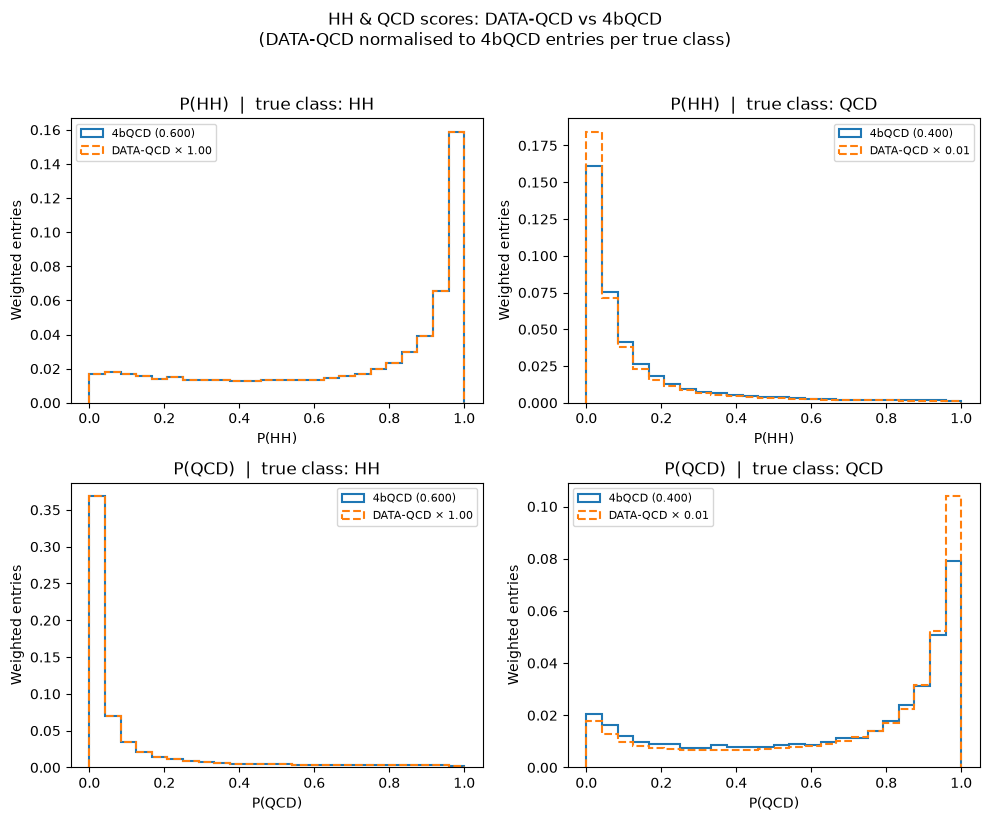

saved HH_QCD_scores_DATAvsQCD_4bQCD_normalised.png


In [13]:

# Compare HH and QCD scores between:
#   - HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued   (DATA QCD, reference for shape)
#   - HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continued  (4b QCD, sets the normalisation target)
#
# For each true class the DATA-QCD histogram is rescaled so its weighted integral
# matches the weighted entries of the 4bQCD sample in that class.

smp_data  = "HH_ZZ_ZH_QCD_ste2_PhaseB_v2_continued"
smp_4bQCD = "HH_ZZ_ZH_4bQCD_ste2_PhaseB_v2_continued"

score_indices  = [0, 1]          # columns in y_pred_probs
score_labels   = ["HH", "QCD"]  # names of those scores
true_classes   = [0, 1]         # 0=HH, 1=QCD in both samples
true_names     = ["HH", "QCD"]

bins = np.linspace(0, 1, 25)

fig, axes = plt.subplots(
    len(score_indices), len(true_classes),
    figsize=(5 * len(true_classes), 4 * len(score_indices)),
    sharey=False,
)

for row, (score_idx, score_name) in enumerate(zip(score_indices, score_labels)):
    for col, (true_idx, true_name) in enumerate(zip(true_classes, true_names)):
        ax = axes[row, col]

        # ── 4bQCD sample (reference, solid) ──────────────────────────────────
        mask_4b   = data[smp_4bQCD]["y_true"] == true_idx
        w_4b      = data[smp_4bQCD]["weight"][mask_4b]
        scores_4b = data[smp_4bQCD]["y_pred_probs"][mask_4b, score_idx]
        n_4b      = w_4b.sum()

        ax.hist(scores_4b, bins=bins, weights=w_4b,
                histtype="step", linewidth=1.5,
                label=f"4bQCD ({n_4b:.3f})")

        # ── DATA-QCD sample normalised to 4bQCD entries for this class ───────
        mask_data   = data[smp_data]["y_true"] == true_idx
        w_data      = data[smp_data]["weight"][mask_data]
        scores_data = data[smp_data]["y_pred_probs"][mask_data, score_idx]
        n_data      = w_data.sum()

        scale = n_4b / n_data if n_data > 0 else 1.0
        ax.hist(scores_data, bins=bins, weights=w_data * scale,
                histtype="step", linewidth=1.5, linestyle="--",
                label=f"DATA-QCD × {scale:.2f}")

        ax.set_xlabel(f"P({score_name})")
        ax.set_ylabel("Weighted entries")
        ax.set_title(f"P({score_name})  |  true class: {true_name}")
        ax.legend(fontsize=8)

fig.suptitle(
    "HH & QCD scores: DATA-QCD vs 4bQCD\n"
    "(DATA-QCD normalised to 4bQCD entries per true class)",
    y=1.02,
)
fig.tight_layout()
fname = "HH_QCD_scores_DATAvsQCD_4bQCD_normalised.png"
fig.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fname}")
